In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm
import xarray as xr

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

Using notebook 3d backend.


# Load data

In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        'LexicalNoDelay',
        'LexicalDelay',
        # 'PictureNaming',
        # 'SentenceRep',
        # 'TIMIT'
        ]


ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'

# HGAs.loc[HGAs.label.str.contains(r'G_precentral', na=False), 'roi'] = 'PrG'
# HGAs.loc[HGAs.label.str.contains(r'G_postcentral', na=False), 'roi'] = 'PoG'
# HGAs.loc[HGAs.label.str.contains(r'G_and_S_subcentral', na=False), 'roi'] = 'Subcentral'
 
HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'

HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'

HGAs.head()

100%|██████████| 824/824 [00:07<00:00, 106.59it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


In [4]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0032_LAI4-5', 'D0040_L1IF3-4', 'D0084_RFAI1-2', 'D0086_LTPI2-3', 'D0090_RIA4-5', 'D0096_LFAI2-3', 'D0096_LFAI4-5', 'D0102_RFAI2-3', 'D0106_LTAS2-3', 'D0121_LFMI3-4', 'D0122_LFAI3-4', 'D0125_LIA4-5', 'D0125_LIA7-8']


In [5]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 214400
PIC electrode count: 178240


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


# Load xcorr

In [6]:
tasks = ["LexicalDelay", "PhonemeSequence"]
ref = "bipolar"

all_ds = []
all_clusters = []

for task_name in tasks:
    results_root = f"../results/{task_name}({ref})"

    base = BIDSPath(
        root=results_root,
        datatype="xcorr",
        task=task_name,
        recording="highgamma",
        description='Repeat',
        suffix="perm",
        check=False,
    )

    nc_paths = base.copy().update(extension=".nc").match()
    csv_paths = base.copy().update(extension=".csv").match()

    print(f"[{task_name}] nc={len(nc_paths)} csv={len(csv_paths)}")

    # load nc
    for p in nc_paths:
        ds = xr.load_dataset(p)
        ds = ds.assign_attrs({
            **ds.attrs,
            "task": task_name,
            "phase": p.processing,
            "description": p.description,
            "file": str(p.fpath),
        })
        all_ds.append(ds)

    # load csv
    for p in csv_paths:
        df = pd.read_csv(p.fpath)
        df["task"] = task_name
        df["phase"] = p.processing
        df["description"] = p.description
        df["file"] = str(p.fpath)
        all_clusters.append(df)

ds_all = xr.concat(all_ds, dim="pair") if all_ds else None
clusters_df = pd.concat(all_clusters, ignore_index=True) if all_clusters else pd.DataFrame()

print("Total datasets loaded:", len(all_ds))
print("Total cluster tables loaded:", len(all_clusters))
print("Total cluster rows:", len(clusters_df))
clusters_df.head()

[LexicalDelay] nc=174 csv=174
[PhonemeSequence] nc=124 csv=124
Total datasets loaded: 298
Total cluster tables loaded: 298
Total cluster rows: 15032


,pair_idx,source_channel,target_channel,lag_start_s,lag_end_s,mass,p_value,significant,task,phase,description,file
0,0,D0023_RPIF2-3,D0023_RPIF7-8,-0.070312,0.078125,0.243481,0.000999,True,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
1,1,D0023_RPIF2-3,D0023_RPIF4-5,-0.078125,0.132812,1.077675,0.000999,True,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
2,3,D0023_RPIF2-3,D0023_RPIF9-10,-0.078125,0.148438,0.351202,0.000999,True,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
3,4,D0023_RPIF2-3,D0023_RPIF8-9,-0.085938,0.070312,0.289358,0.000999,True,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
4,5,D0023_RPIF7-8,D0023_RPIF4-5,-0.054688,0.046875,0.131312,0.021978,True,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...


In [7]:
# --- simplest global merge for multi-task + multi-phase ---
# no xcorr_task / xcorr_phase filter

# 1) global channel metadata
channel_meta = (
    HGAs[["channel", "roi", "hemi"]]
    .dropna()
    .groupby(["channel", "roi", "hemi"], as_index=False)
    .size()
    .sort_values(["channel", "size"], ascending=[True, False])
    .drop_duplicates("channel")
    .drop(columns="size")
)

# 2) merge to significant clusters (all tasks/phases already in clusters_df)
sig_roi_df = (
    clusters_df.loc[clusters_df["significant"] == True].copy()
    .merge(
        channel_meta.rename(columns={
            "channel": "source_channel",
            "roi": "source_roi",
            "hemi": "source_hemi"
        }),
        on="source_channel",
        how="left",
    )
    .merge(
        channel_meta.rename(columns={
            "channel": "target_channel",
            "roi": "target_roi",
            "hemi": "target_hemi"
        }),
        on="target_channel",
        how="left",
    )
)

# 3) quick QC
print("sig rows:", len(sig_roi_df))
print("missing source_roi:", sig_roi_df["source_roi"].isna().sum())
print("missing target_roi:", sig_roi_df["target_roi"].isna().sum())
print("missing source_hemi:", sig_roi_df["source_hemi"].isna().sum())
print("missing target_hemi:", sig_roi_df["target_hemi"].isna().sum())

sig_roi_df.head(10)

sig rows: 15032
missing source_roi: 22
missing target_roi: 52
missing source_hemi: 22
missing target_hemi: 52


,pair_idx,source_channel,target_channel,lag_start_s,lag_end_s,mass,p_value,significant,task,phase,description,file,source_roi,source_hemi,target_roi,target_hemi
0,0,D0023_RPIF2-3,D0023_RPIF7-8,-0.070312,0.078125,0.243481,0.000999,True,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,Sylvian,R,Intersection,R
1,1,D0023_RPIF2-3,D0023_RPIF4-5,-0.078125,0.132812,1.077675,0.000999,True,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,Sylvian,R,Intersection,R
2,3,D0023_RPIF2-3,D0023_RPIF9-10,-0.078125,0.148438,0.351202,0.000999,True,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,Sylvian,R,AG,R
3,4,D0023_RPIF2-3,D0023_RPIF8-9,-0.085938,0.070312,0.289358,0.000999,True,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,Sylvian,R,AG,R
4,5,D0023_RPIF7-8,D0023_RPIF4-5,-0.054688,0.046875,0.131312,0.021978,True,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,Intersection,R,Intersection,R
5,6,D0023_RPIF7-8,D0023_RPSF1-2,-0.718750,-0.492188,0.183577,0.002997,True,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,Intersection,R,CGs,R
6,9,D0023_RPIF7-8,D0023_RPIF9-10,-0.132812,0.078125,0.290341,0.000999,True,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,Intersection,R,AG,R
7,9,D0023_RPIF7-8,D0023_RPIF9-10,0.750000,0.906250,0.102657,0.011988,True,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,Intersection,R,AG,R
8,11,D0023_RPIF4-5,D0023_RPIF1-2,-0.085938,0.078125,0.403853,0.000999,True,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,Intersection,R,Sylvian,R
9,12,D0023_RPIF4-5,D0023_RPIF9-10,-0.109375,0.046875,0.221361,0.001998,True,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,Intersection,R,AG,R


In [8]:
from pathlib import Path

# ===== config =====
min_peak_val = 0.01      # 强度阈值
max_abs_lag_s = 0.5       # lag范围阈值（秒）

# Cache datasets by file to avoid repeated I/O
ds_cache = {}

def get_ds(nc_file):
    if nc_file not in ds_cache:
        ds_cache[nc_file] = xr.load_dataset(nc_file)
    return ds_cache[nc_file]

# Work on significant clusters only
sig = sig_roi_df.copy()

# robust csv -> nc path
sig["nc_file"] = sig["file"].apply(lambda x: str(Path(x).with_suffix(".nc")))

peak_rows = []
n_skip_pair_idx = 0
n_skip_empty_window = 0
n_skip_all_nan = 0

for _, row in sig.iterrows():
    nc_file = row["nc_file"]
    pair_idx = int(row["pair_idx"])
    lag_start = float(row["lag_start_s"])
    lag_end = float(row["lag_end_s"])

    ds = get_ds(nc_file)

    # Guard against out-of-range pair index
    if pair_idx < 0 or pair_idx >= ds.sizes["pair"]:
        n_skip_pair_idx += 1
        continue

    obs = ds["observed_curve"].isel(pair=pair_idx).values
    nul = ds["null_mean"].isel(pair=pair_idx).values
    lag = ds["lag"].values

    # cluster window
    mask = (lag >= lag_start) & (lag <= lag_end)
    if not mask.any():
        n_skip_empty_window += 1
        continue

    obs_in_cluster = obs[mask]
    lag_in_cluster = lag[mask]

    if not np.isfinite(obs_in_cluster).any():
        n_skip_all_nan += 1
        continue

    # peak within cluster
    peak_idx_local = np.nanargmax(obs_in_cluster)
    peak_lag = float(lag_in_cluster[peak_idx_local])
    peak_val = float(obs_in_cluster[peak_idx_local])

    # null mean at nearest lag
    peak_idx_global = int(np.argmin(np.abs(lag - peak_lag)))
    null_at_peak = float(nul[peak_idx_global])
    peak_excess = peak_val - null_at_peak

    # cluster interval (normalized: left <= right)
    cluster_left = min(lag_start, lag_end)
    cluster_right = max(lag_start, lag_end)
    cluster_mid = 0.5 * (lag_start + lag_end)

    # flags
    is_near_zero = abs(peak_lag) < 0.05
    in_range = abs(peak_lag) <= max_abs_lag_s

    if peak_lag > 0.01:
        direction = "source_leads"
    elif peak_lag < -0.01:
        direction = "target_leads"
    else:
        direction = "sync"

    peak_rows.append({
        "pair_idx": pair_idx,
        "source_channel": row["source_channel"],
        "target_channel": row["target_channel"],
        "source_roi": row.get("source_roi"),
        "target_roi": row.get("target_roi"),
        "source_hemi": row.get("source_hemi"),
        "target_hemi": row.get("target_hemi"),
        "lag_start_s": lag_start,
        "lag_end_s": lag_end,
        "cluster_left_s": cluster_left,
        "cluster_right_s": cluster_right,
        "cluster_mid_s": cluster_mid,
        "cluster_width_s": lag_end - lag_start,
        "cluster_mass": row["mass"],
        "p_value": row["p_value"],
        "peak_lag_s": peak_lag,
        "peak_val": peak_val,
        "null_at_peak": null_at_peak,
        "peak_excess": peak_excess,
        "is_near_zero": is_near_zero,
        "in_range": in_range,
        "direction": direction,
        "task": row.get("task"),
        "phase": row.get("phase"),
        "description": row.get("description"),
        "file": row["file"],
    })

peaks_df_raw = pd.DataFrame(peak_rows)

# ===== post-filter for downstream analysis =====
peaks_df = peaks_df_raw[
    (peaks_df_raw["peak_val"] >= min_peak_val) &
    (peaks_df_raw["peak_lag_s"].abs() <= max_abs_lag_s)
].copy()

print(f"Total significant clusters (raw): {len(peaks_df_raw)}")
print(f"After filter peak_val>={min_peak_val} & |lag|<={max_abs_lag_s}s: {len(peaks_df)}")
print(f"Removed by filter: {len(peaks_df_raw) - len(peaks_df)}")
print(f"Near-zero peaks (|lag|<0.05s): {peaks_df['is_near_zero'].sum()}")
print(f"Out-of-range peaks: {(~peaks_df['in_range']).sum()}")
print(f"Skipped (pair_idx out of range): {n_skip_pair_idx}")
print(f"Skipped (empty lag window): {n_skip_empty_window}")
print(f"Skipped (all-NaN in cluster window): {n_skip_all_nan}")

peaks_df.head()

Total significant clusters (raw): 15032
After filter peak_val>=0.01 & |lag|<=0.5s: 14079
Removed by filter: 953
Near-zero peaks (|lag|<0.05s): 8077
Out-of-range peaks: 0
Skipped (pair_idx out of range): 0
Skipped (empty lag window): 0
Skipped (all-NaN in cluster window): 0


,pair_idx,source_channel,target_channel,source_roi,target_roi,source_hemi,target_hemi,lag_start_s,lag_end_s,cluster_left_s,...,peak_val,null_at_peak,peak_excess,is_near_zero,in_range,direction,task,phase,description,file
0,0,D0023_RPIF2-3,D0023_RPIF7-8,Sylvian,Intersection,R,R,-0.070312,0.078125,-0.070312,...,0.056195,0.038233,0.017961,True,True,sync,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
1,1,D0023_RPIF2-3,D0023_RPIF4-5,Sylvian,Intersection,R,R,-0.078125,0.132812,-0.078125,...,0.177520,0.110792,0.066728,True,True,sync,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
2,3,D0023_RPIF2-3,D0023_RPIF9-10,Sylvian,AG,R,R,-0.078125,0.148438,-0.078125,...,0.061130,0.042736,0.018394,True,True,target_leads,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
3,4,D0023_RPIF2-3,D0023_RPIF8-9,Sylvian,AG,R,R,-0.085938,0.070312,-0.085938,...,0.058793,0.038895,0.019898,True,True,sync,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
4,5,D0023_RPIF7-8,D0023_RPIF4-5,Intersection,Intersection,R,R,-0.054688,0.046875,-0.054688,...,0.047605,0.035946,0.011659,True,True,sync,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...


In [9]:
# 在这里先做 ROI 合并，再做 base 筛选
base = "AIC"  # 或 "AIC"

roi_map = {
    "MFGs": "MFG",
    "IFGs": "IFG",
    "SFGs": "SFG",
    "OFCs": "OFC",
}

df = peaks_df.copy()

# 一开始就统一 ROI 标签
df["source_roi"] = df["source_roi"].replace(roi_map)
df["target_roi"] = df["target_roi"].replace(roi_map)

# 然后再按 base 取边
aic_edges = df[
    ((df["source_roi"] == base) | (df["target_roi"] == base)) &
    (df["source_roi"] != "Intersection") &
    (df["target_roi"] != "Intersection")
].copy()

aic_edges.head()

,pair_idx,source_channel,target_channel,source_roi,target_roi,source_hemi,target_hemi,lag_start_s,lag_end_s,cluster_left_s,...,peak_val,null_at_peak,peak_excess,is_near_zero,in_range,direction,task,phase,description,file
152,20,D0027_LMSF3-4,D0027_LAI3-4,dACC,AIC,L,L,-0.062500,0.070312,-0.062500,...,0.033774,0.024375,0.009399,True,True,target_leads,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0027/xco...
156,33,D0027_LMSF7-8,D0027_LAI3-4,SFG,AIC,L,L,-0.359375,0.023438,-0.359375,...,0.037629,0.024879,0.012751,False,True,target_leads,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0027/xco...
159,37,D0027_LMSF7-8,D0027_LAI2-3,SFG,AIC,L,L,-0.195312,0.007812,-0.195312,...,0.032671,0.025125,0.007547,True,True,target_leads,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0027/xco...
161,40,D0027_LAI3-4,D0027_LMSF6-7,AIC,SFG,L,L,-0.015625,0.218750,-0.015625,...,0.031815,0.024243,0.007572,False,True,source_leads,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0027/xco...
174,95,D0027_LMSF7-8,D0027_LAI3-4,SFG,AIC,L,L,-0.265625,-0.148438,-0.265625,...,0.030464,0.022455,0.008009,False,True,target_leads,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0027/xco...


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_1542062/27269375.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(sub_vals), 1))


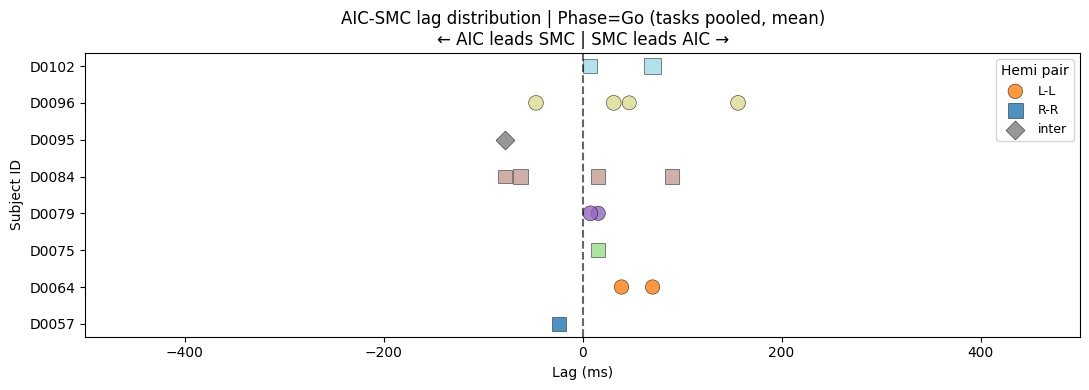

rows before aggregation: 22
rows after aggregation: 17
subjects: 8
hemi_type
L-L      8
R-R      8
inter    1
dtype: int64


In [10]:
# ===== config =====
base = "AIC"
roi = "SMC"
phase_keep = "go"

# ===== 1) filter ROI pair + phase =====
df = peaks_df.copy()
roi_map = {"MFGs":"MFG","IFGs":"IFG","SFGs":"SFG","OFCs":"OFC"}
df["source_roi"] = df["source_roi"].replace(roi_map)
df["target_roi"] = df["target_roi"].replace(roi_map)

plot_df = df[
    (
        ((df["source_roi"] == base) & (df["target_roi"] == roi)) |
        ((df["source_roi"] == roi) & (df["target_roi"] == base))
    ) &
    (df["phase"].astype(str).str.lower() == phase_keep)
].copy()

if plot_df.empty:
    raise RuntimeError(f"No rows found for {base}-{roi} in phase={phase_keep}")

# ===== 2) subject + unified direction =====
plot_df["subject"] = plot_df["source_channel"].str.extract(r"^(D\d+)_")[0]
plot_df["lag_aic_leads"] = np.where(
    plot_df["source_roi"] == base,
    plot_df["peak_lag_s"],
    -plot_df["peak_lag_s"]
)

# ===== 2.5) hemisphere pair type =====
src_h = plot_df["source_hemi"].astype(str).str.strip().str.lower().str[0]  # 'l' or 'r'
tgt_h = plot_df["target_hemi"].astype(str).str.strip().str.lower().str[0]

def hemi_type(s, t):
    if s == t == "l":
        return "L-L"
    elif s == t == "r":
        return "R-R"
    else:
        return "inter"

plot_df["hemi_type"] = [hemi_type(s, t) for s, t in zip(src_h, tgt_h)]

# ===== 3) undirected pair key =====
ab = np.sort(plot_df[["source_channel", "target_channel"]].values, axis=1)
plot_df["ch_a"], plot_df["ch_b"] = ab[:, 0], ab[:, 1]

# ===== 4) pool across tasks by MEAN (keep hemi_type) =====
plot_df_mean = (
    plot_df.groupby(["subject", "description", "ch_a", "ch_b", "hemi_type"], as_index=False)
           .agg(
               lag_aic_leads=("lag_aic_leads", "mean"),
               peak_val=("peak_val", "mean"),
               peak_excess=("peak_excess", "mean"),
               n_obs=("lag_aic_leads", "size"),
           )
)

# 去掉 |lag| < 5 ms 的点
plot_df_mean = plot_df_mean[plot_df_mean["lag_aic_leads"].abs() >= 0.005].copy()

if plot_df_mean.empty:
    raise RuntimeError("No rows after aggregation.")

# ===== 5) y mapping =====
subjects = sorted(plot_df_mean["subject"].dropna().unique())
sub_to_y = {s: i for i, s in enumerate(subjects)}
plot_df_mean["y"] = plot_df_mean["subject"].map(sub_to_y)

# ===== 6) color by subject =====
sub_vals = sorted(plot_df_mean["subject"].astype(str).unique())
cmap = plt.cm.get_cmap("tab20", max(len(sub_vals), 1))
sub_to_color = {s: cmap(i) for i, s in enumerate(sub_vals)}

# point size by peak_val mean
vmax = plot_df_mean["peak_val"].max()
if pd.isna(vmax) or vmax <= 0:
    sizes = np.full(len(plot_df_mean), 40.0)
else:
    sizes = (plot_df_mean["peak_val"] / vmax * 120 + 20).values

# ===== 7) plot with different markers =====
marker_map = {"L-L": "o", "R-R": "s", "inter": "D"}

fig, ax = plt.subplots(figsize=(11, max(4, 0.45 * len(subjects))))

for ht, marker in marker_map.items():
    sub = plot_df_mean[plot_df_mean["hemi_type"] == ht]
    if sub.empty:
        continue
    idx = sub.index
    ax.scatter(
        sub["lag_aic_leads"] * 1000,
        sub["y"],
        s=sizes[plot_df_mean.index.get_indexer(idx)],
        c=[sub_to_color[s] for s in sub["subject"]],
        marker=marker,
        alpha=0.8,
        edgecolors="k",
        linewidths=0.4,
        label=ht,
    )

ax.axvline(0, ls="--", color="k", alpha=0.6)
ax.set_yticks(range(len(subjects)))
ax.set_yticklabels(subjects)
ax.set_xlabel("Lag (ms)")
ax.set_ylabel("Subject ID")
ax.set_title(
    f"{base}-{roi} lag distribution | Phase={phase_keep.capitalize()} "
    f"(tasks pooled, mean)\n← {base} leads {roi} | {roi} leads {base} →"
)
ax.set_xlim(-500, 500)
ax.legend(title="Hemi pair", loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

print("rows before aggregation:", len(plot_df))
print("rows after aggregation:", len(plot_df_mean))
print("subjects:", len(subjects))
print(plot_df_mean.groupby("hemi_type").size())


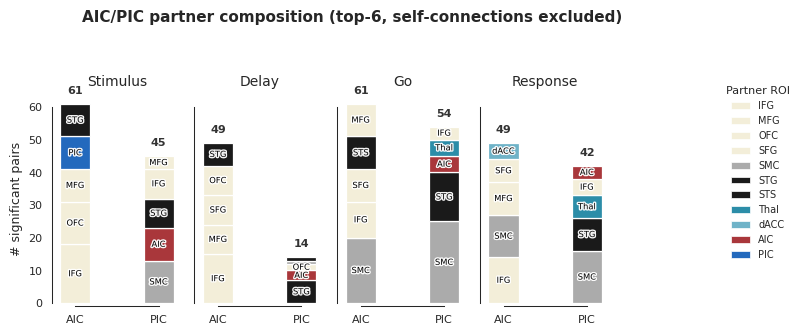

In [11]:
import matplotlib.patheffects as pe

# ===================== config =====================
# phases = ["stimulus", "delay", "go", "response"]

phases = ["stimulus", "delay", "go", "response"]
focus_rois = ["AIC", "PIC"]
top_k = 5

# label controls
label_inside_min = 2      # larger threshold: only big segments get inside text
max_outside_labels = 0    # disable outside callouts (cleaner)

exclude_rois = {"Intersection", "LinG", "OccS", "CollatAnt", "Central"}
roi_map = {"MFGs": "MFG", "IFGs": "IFG", "SFGs": "SFG", "OFCs": "OFC"}

# ===================== prepare =====================
df = peaks_df.copy()
df["source_roi"] = df["source_roi"].replace(roi_map)
df["target_roi"] = df["target_roi"].replace(roi_map)
df["phase_norm"] = df["phase"].astype(str).str.lower().str.strip()

max_abs_lag_ms = 500
df = df[df["peak_lag_s"].abs() <= max_abs_lag_ms / 1000].copy()

df = df.dropna(subset=["source_roi", "target_roi", "source_channel", "target_channel", "phase_norm"])
df = df[
    (~df["source_roi"].isin(exclude_rois)) &
    (~df["target_roi"].isin(exclude_rois)) &
    (df["phase_norm"].isin(phases))
].copy()

ab = np.sort(df[["source_channel", "target_channel"]].values, axis=1)
df["pair_key"] = ab[:, 0] + "||" + ab[:, 1]

rows = []
for focus in focus_rois:
    tmp = df[(df["source_roi"] == focus) | (df["target_roi"] == focus)].copy()
    tmp = tmp[~((tmp["source_roi"] == focus) & (tmp["target_roi"] == focus))].copy()
    if tmp.empty:
        continue
    tmp["focus_roi"] = focus
    tmp["partner_roi"] = np.where(tmp["source_roi"] == focus, tmp["target_roi"], tmp["source_roi"])
    rows.append(tmp[["phase_norm", "focus_roi", "partner_roi", "pair_key"]])

if not rows:
    raise RuntimeError("No rows left after filtering.")

long_df = pd.concat(rows, ignore_index=True)

agg = (
    long_df.groupby(["phase_norm", "focus_roi", "partner_roi"], as_index=False)
           .agg(n_pairs=("pair_key", "nunique"))
)

top_chunks = []
for ph in phases:
    for focus in focus_rois:
        sub = agg[(agg["phase_norm"] == ph) & (agg["focus_roi"] == focus)].copy()
        if sub.empty:
            continue
        sub = sub.sort_values("n_pairs", ascending=False).head(top_k)
        top_chunks.append(sub)

if not top_chunks:
    raise RuntimeError("No top-k partners found.")

top_df = pd.concat(top_chunks, ignore_index=True)

# ===================== region-family color mapping =====================
partners = sorted(top_df["partner_roi"].unique())

partner2color = {
    "IFG": "#f3eed9",
    "MFG": "#f3eed9",
    "OFC": "#f3eed9",
    "SFG": "#f3eed9",
    "SMC": "#ababab",
    "STG": "#1A1A1A",
    "STS": "#1A1A1A",
    "Thal": "#2C8DA8",
    "dACC": "#6FB3C8",
    "AIC": red,
    "PIC": blue,
}

fallback_color = "#bdbdbd"
for p in partners:
    if p not in partner2color:
        partner2color[p] = fallback_color

# ===================== plot =====================
sns.set_theme(style="white")
fig, axes = plt.subplots(1, len(phases), figsize=(1.8 * len(phases), 3.4), sharey=True)
if len(phases) == 1:
    axes = [axes]

for ax, ph in zip(axes, phases):
    x_pos = np.array([0, 1])
    bar_width = 0.36
    totals = []

    for i, focus in enumerate(focus_rois):
        sub = top_df[(top_df["phase_norm"] == ph) & (top_df["focus_roi"] == focus)].copy()
        bottom = 0
        if sub.empty:
            totals.append(0)
            continue

        for _, r in sub.sort_values("n_pairs", ascending=False).iterrows():
            v = r["n_pairs"]
            p = r["partner_roi"]

            ax.bar(
                x_pos[i], v, width=bar_width, bottom=bottom,
                color=partner2color[p], edgecolor="white", linewidth=0.9
            )

            y_center = bottom + v / 2
            if v >= label_inside_min:
                t = ax.text(
                    x_pos[i], y_center, p,
                    ha="center", va="center", fontsize=6, fontweight="medium", color="black"
                )
                t.set_path_effects([pe.withStroke(linewidth=2, foreground="white", alpha=0.95)])

            bottom += v

        totals.append(bottom)

    # title per panel
    ax.set_title(ph.capitalize(), fontsize=10, fontweight="medium", pad=6)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(focus_rois, fontsize=8)
    ax.tick_params(labelsize=8, width=0.8, length=3, which="both")

    for spine in ax.spines.values():
        spine.set_linewidth(0.75)
    sns.despine(ax=ax, offset=2, trim=True)

    # total labels (moved higher to avoid overlap)
    for i, t in enumerate(totals):
        ax.text(x_pos[i], t + 2.5, f"{int(t)}", ha="center", va="bottom", fontsize=8, fontweight="bold", color="#333")

axes[0].set_ylabel("# significant pairs", fontsize=9)
for ax in axes[1:]:
    ax.set_ylabel("")

# legend: only actually appearing partners, right side
legend_order = ["IFG", "MFG", "OFC", "SFG", "SMC", "STG", "STS", "Thal", "dACC", "AIC", "PIC"]
legend_partners = [p for p in legend_order if p in partners] + [p for p in partners if p not in legend_order]

handles = [plt.Rectangle((0, 0), 1, 1, color=partner2color[p], ec="white", lw=0.5) for p in legend_partners]
fig.legend(
    handles, legend_partners, title="Partner ROI",
    loc="center right", bbox_to_anchor=(1.12, 0.5),
    ncol=1, frameon=False, fontsize=7, title_fontsize=8
)

fig.suptitle("AIC/PIC partner composition (top-6, self-connections excluded)", fontsize=11, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 0.88, 0.94])
plt.savefig("../img/misc/xcorr_partner_composition.svg", dpi=300, bbox_inches="tight")
plt.show()

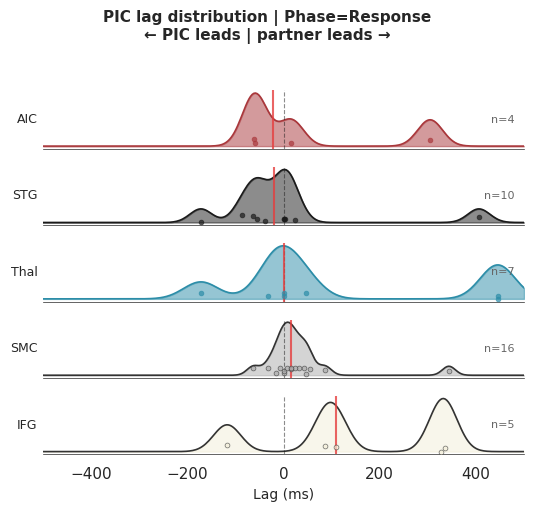

Partners shown: ['AIC', 'STG', 'Thal', 'SMC', 'IFG']
Total pairs: 42


In [12]:
from scipy.stats import gaussian_kde

# ===================== config =====================
phase_keep = "response"
focus_roi = "PIC"
top_k = 5

exclude_rois = {"Intersection", "LinG", "OccS", "CollatAnt", "Central"}
roi_map = {"MFGs": "MFG", "IFGs": "IFG", "SFGs": "SFG", "OFCs": "OFC"}

# ROI color mapping (same as stacked bar)
partner2color = {
    "IFG": "#f3eed9",
    "MFG": "#f3eed9",
    "OFC": "#f3eed9",
    "SFG": "#f3eed9",
    "SMC": "#ababab",
    "STG": "#1A1A1A",
    "STS": "#1A1A1A",
    "Thal": "#2C8DA8",
    "dACC": "#6FB3C8",
    "AIC": red,
    "PIC": blue,
}
fallback_color = "#4C72B0"

# ===================== prepare =====================
df = peaks_df.copy()
df["source_roi"] = df["source_roi"].replace(roi_map)
df["target_roi"] = df["target_roi"].replace(roi_map)
df["phase_norm"] = df["phase"].astype(str).str.lower().str.strip()

df = df[
    (~df["source_roi"].isin(exclude_rois)) &
    (~df["target_roi"].isin(exclude_rois)) &
    (df["phase_norm"] == phase_keep)
].copy()

mask = (df["source_roi"] == focus_roi) | (df["target_roi"] == focus_roi)
df = df[mask].copy()
df = df[~((df["source_roi"] == focus_roi) & (df["target_roi"] == focus_roi))].copy()

df["partner_roi"] = np.where(df["source_roi"] == focus_roi, df["target_roi"], df["source_roi"])
df["lag_focus_leads"] = np.where(
    df["source_roi"] == focus_roi,
    df["peak_lag_s"],
    -df["peak_lag_s"]
)

ab = np.sort(df[["source_channel", "target_channel"]].values, axis=1)
df["pair_key"] = ab[:, 0] + "||" + ab[:, 1]

agg = (
    df.groupby(["partner_roi", "pair_key"], as_index=False)
      .agg(lag_focus_leads=("lag_focus_leads", "mean"))
)

partner_counts = agg.groupby("partner_roi").size().sort_values(ascending=False)
top_partners = partner_counts.head(top_k).index.tolist()
agg = agg[agg["partner_roi"].isin(top_partners)].copy()

partner_order = (
    agg.groupby("partner_roi")["lag_focus_leads"]
       .median()
       .sort_values()
       .index.tolist()
)

# ===================== ridgeline plot =====================
fig, axes = plt.subplots(
    len(partner_order), 1,
    figsize=(5.5, 1.0 * len(partner_order)),
    sharex=True
)
if len(partner_order) == 1:
    axes = [axes]

x_grid = np.linspace(-0.5, 0.5, 300)

for ax, partner in zip(axes, partner_order):
    sub = agg[agg["partner_roi"] == partner]["lag_focus_leads"].values
    n = len(sub)
    color = partner2color.get(partner, fallback_color)
    
    # for light colors, use darker edge
    edge_color = "#333" if color in ["#f3eed9", "#ababab"] else color
    
    if n < 2:
        ax.set_ylabel(partner, rotation=0, ha="right", va="center", fontsize=9)
        ax.set_yticks([])
        ax.text(0.98, 0.5, f"n={n}", transform=ax.transAxes, ha="right", va="center", fontsize=8, color="#666")
        continue
    
    # KDE
    kde = gaussian_kde(sub, bw_method=0.15)
    density = kde(x_grid)
    
    # fill with ROI color
    ax.fill_between(x_grid * 1000, density, alpha=0.5, color=color)
    ax.plot(x_grid * 1000, density, color=edge_color, lw=1.2)
    
    # individual points on x-axis (jittered y for visibility)
    jitter = np.random.uniform(0, density.max() * 0.15, size=n)
    ax.scatter(
        sub * 1000, jitter,
        s=12, c=color, edgecolors=edge_color, linewidths=0.5,
        alpha=0.7, zorder=3
    )
    
    # zero line
    ax.axvline(0, color="k", ls="--", lw=0.8, alpha=0.5)
    
    # median marker
    med = np.median(sub) * 1000
    ax.axvline(med, color="#E53E3E", ls="-", lw=1.5, alpha=0.8)
    
    # ROI label
    ax.set_ylabel(partner, rotation=0, ha="right", va="center", fontsize=9)
    ax.set_yticks([])
    
    # n count on right side
    ax.text(0.98, 0.5, f"n={n}", transform=ax.transAxes, ha="right", va="center", fontsize=8, color="#666")
    
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.5)

axes[-1].set_xlabel("Lag (ms)", fontsize=10)
axes[-1].set_xlim(-500, 500)

fig.suptitle(
    f"{focus_roi} lag distribution | Phase={phase_keep.capitalize()}\n"
    f"← {focus_roi} leads | partner leads →",
    fontsize=11, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.show()

print(f"Partners shown: {partner_order}")
print(f"Total pairs: {len(agg)}")

Filtered to |lag| <= 500 ms, remaining rows: 140
Partners: ['AIC', 'SFG', 'PIC', 'STG', 'MFG', 'STS']
Subjects: ['D0023', 'D0024', 'D0047', 'D0054', 'D0055', 'D0058', 'D0061', 'D0064', 'D0068', 'D0075', 'D0079', 'D0080', 'D0081', 'D0084', 'D0094', 'D0096', 'D0102', 'D0127']
Total pairs: 60


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_1542062/1377435986.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(len(subjects), 1))


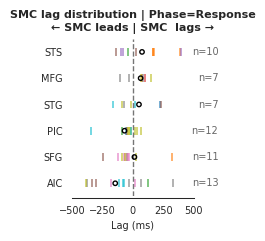

In [26]:
# ===================== config =====================
phase_keep = "response"
focus_roi = "SMC"
top_k = 6

exclude_rois = {"Intersection", "LinG", "OccS", "CollatAnt", "Central"}
roi_map = {"MFGs": "MFG", "IFGs": "IFG", "SFGs": "SFG", "OFCs": "OFC"}

# ===================== prepare =====================
df = peaks_df.copy()
df["source_roi"] = df["source_roi"].replace(roi_map)
df["target_roi"] = df["target_roi"].replace(roi_map)
df["phase_norm"] = df["phase"].astype(str).str.lower().str.strip()

df = df[
    (~df["source_roi"].isin(exclude_rois)) &
    (~df["target_roi"].isin(exclude_rois)) &
    (df["phase_norm"] == phase_keep)
].copy()

mask = (df["source_roi"] == focus_roi) | (df["target_roi"] == focus_roi)
df = df[mask].copy()
df = df[~((df["source_roi"] == focus_roi) & (df["target_roi"] == focus_roi))].copy()

df["partner_roi"] = np.where(df["source_roi"] == focus_roi, df["target_roi"], df["source_roi"])
df["lag_focus_leads"] = np.where(
    df["source_roi"] == focus_roi,
    df["peak_lag_s"],
    -df["peak_lag_s"]
)
max_abs_lag_ms = 500
df = df[df["lag_focus_leads"].abs() <= max_abs_lag_ms / 1000].copy()

print(f"Filtered to |lag| <= {max_abs_lag_ms} ms, remaining rows: {len(df)}")

# extract subject
df["subject"] = df["source_channel"].str.extract(r"^(D\d+)_")[0]

# undirected pair key
ab = np.sort(df[["source_channel", "target_channel"]].values, axis=1)
df["pair_key"] = ab[:, 0] + "||" + ab[:, 1]

# aggregate by pair (mean across tasks/descriptions), keep subject
agg = (
    df.groupby(["partner_roi", "pair_key", "subject"], as_index=False)
      .agg(lag_focus_leads=("lag_focus_leads", "mean"))
)

# 去掉 |lag| < 10 ms 的点（接近 0 的点）
min_lag_ms = 10  # 可调整阈值
agg = agg[agg["lag_focus_leads"].abs() >= min_lag_ms / 1000].copy()

# select top-k partners by count
partner_counts = agg.groupby("partner_roi").size().sort_values(ascending=False)
top_partners = partner_counts.head(top_k).index.tolist()
agg = agg[agg["partner_roi"].isin(top_partners)].copy()

# order partners by median lag
partner_order = (
    agg.groupby("partner_roi")["lag_focus_leads"]
       .median()
       .sort_values()
       .index.tolist()
)

# ===================== strip plot (no KDE) =====================
fig, ax = plt.subplots(figsize=(4*cm, (0.7 * len(partner_order) + 1) * cm))

# subject color mapping
subjects = sorted(agg["subject"].dropna().unique())
cmap = plt.cm.get_cmap("tab10", max(len(subjects), 1))
sub_to_color = {s: cmap(i) for i, s in enumerate(subjects)}

# y positions for each partner ROI
partner_to_y = {p: i for i, p in enumerate(partner_order)}


# 替换原来的 scatter 循环
for _, row in agg.iterrows():
    partner = row["partner_roi"]
    lag_ms = row["lag_focus_leads"] * 1000
    subj = row["subject"]
    y = partner_to_y[partner]
    
    ax.vlines(
        lag_ms, y - 0.15, y + 0.15,
        colors=sub_to_color[subj], linewidths=1.2, alpha=0.7
    )
    
# mean marker (one circle per partner ROI)
# subject-balanced center: each subject contributes equally
sub_center = (
    agg.groupby(["partner_roi", "subject"], as_index=False)
       .agg(sub_lag=("lag_focus_leads", "median"))   # subject内先用median更稳
)

center_df = (
    sub_center.groupby("partner_roi", as_index=False)
              .agg(center_lag=("sub_lag", "mean"))   # 再跨subject平均
)

# draw center marker
for _, r in center_df.iterrows():
    partner = r["partner_roi"]
    if partner not in partner_to_y:
        continue
    y = partner_to_y[partner]
    center_ms = r["center_lag"] * 1000
    
    ax.scatter(
        center_ms, y,
        s=10, marker="o",
        facecolor="None", edgecolor="black", linewidth=1,
        zorder=6
    )

# zero line
ax.axvline(0, color="k", ls="--", lw=1, alpha=0.6)

# formatting
ax.set_yticks(range(len(partner_order)))
ax.set_yticklabels(partner_order, fontsize=7)
ax.set_xlabel("Lag (ms)", fontsize=7)
ax.set_xlim(-500, 500)
ax.set_ylim(-0.5, len(partner_order) - 0.5)


ax.tick_params(labelsize=7, width=0.75, length=2, which="both")
for spine in ax.spines.values():
    spine.set_linewidth(0.75)
sns.despine(ax=ax, offset=1, trim=True)

# n count annotations
for partner in partner_order:
    n = len(agg[agg["partner_roi"] == partner])
    y = partner_to_y[partner]
    ax.text(700, y, f"n={n}", ha="right", va="center", fontsize=7, color="#666")

# subject legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sub_to_color[s], 
                       markersize=8, label=s) for s in subjects]
# ax.legend(handles=handles, title="Subject", loc="upper left", bbox_to_anchor=(1.02, 1), 
#           fontsize=8, title_fontsize=9, frameon=False)

ax.set_title(
    f"{focus_roi} lag distribution | Phase={phase_keep.capitalize()}\n"
    f"← {focus_roi} leads | {focus_roi}  lags →",
    fontsize=8, fontweight="bold"
)

sns.despine(ax=ax, left=True)
ax.tick_params(left=False)

print(f"Partners: {partner_order}")
print(f"Subjects: {subjects}")
print(f"Total pairs: {len(agg)}")

fig.savefig(f"../img/misc/xcorr_lag_strip_{focus_roi}_{phase_keep}.svg", dpi=300, bbox_inches="tight")

In [14]:
import numpy as np
import pandas as pd

df = aic_edges.copy()

# 1) 无向 pair key：把 (A,B) 和 (B,A) 视为同一对
pair_sorted = np.sort(df[["source_channel", "target_channel"]].values, axis=1)
df["ch_a"] = pair_sorted[:, 0]
df["ch_b"] = pair_sorted[:, 1]

# 2) 常见数值列（存在才聚合）
num_candidates = [
    "peak_lag_s", "peak_val", "null_at_peak", "peak_excess",
    "cluster_mass", "cluster_width_s", "p_value",
    "lag_start_s", "lag_end_s"
]
num_cols = [c for c in num_candidates if c in df.columns]

agg_dict = {c: "mean" for c in num_cols}
agg_dict.update({
    "is_near_zero": "mean",   # 变成比例
    "in_range": "mean",       # 变成比例
    "phase": lambda s: "|".join(sorted(set(map(str, s)))),
    "description": lambda s: "|".join(sorted(set(map(str, s)))),
    "file": lambda s: len(set(map(str, s))),  # 涉及多少个结果文件
})

# 只保留存在的列
agg_dict = {k: v for k, v in agg_dict.items() if k in df.columns}

pair_mean = (
    df.groupby(["ch_a", "ch_b"], as_index=False)
      .agg(agg_dict)
      .rename(columns={"file": "n_files"})
)

# 3) 统计每个pair被合并了多少行
pair_counts = df.groupby(["ch_a", "ch_b"]).size().rename("n_rows").reset_index()
pair_mean = pair_mean.merge(pair_counts, on=["ch_a", "ch_b"], how="left")

# 4) 给聚合后的pair补回ROI（按channel映射）
ch_roi = pd.concat([
    peaks_df[["source_channel", "source_roi"]].rename(columns={"source_channel":"channel","source_roi":"roi"}),
    peaks_df[["target_channel", "target_roi"]].rename(columns={"target_channel":"channel","target_roi":"roi"}),
], ignore_index=True).dropna().drop_duplicates(["channel", "roi"])

# 一个channel若出现多个roi，取出现次数最多的那个
ch_roi = (
    ch_roi.groupby(["channel", "roi"], as_index=False).size()
          .sort_values(["channel","size"], ascending=[True, False])
          .drop_duplicates("channel")
          .drop(columns="size")
)

pair_mean = (
    pair_mean
    .merge(ch_roi.rename(columns={"channel":"ch_a","roi":"roi_a"}), on="ch_a", how="left")
    .merge(ch_roi.rename(columns={"channel":"ch_b","roi":"roi_b"}), on="ch_b", how="left")
)

display(pair_mean.sort_values("n_rows", ascending=False).head(20))
print("Aggregated unique pairs:", len(pair_mean))

,ch_a,ch_b,peak_lag_s,peak_val,null_at_peak,peak_excess,cluster_mass,cluster_width_s,p_value,lag_start_s,lag_end_s,is_near_zero,in_range,phase,description,n_files,n_rows,roi_a,roi_b
25,D0053_RPI1-2,D0053_RPI6-7,0.057129,0.168758,0.073953,0.094804,1.093141,0.127441,0.000999,-0.006348,0.121094,0.0625,1.0,Delay|Go|Response|Stimulus,Repeat,4,16,PIC,AIC
24,D0053_RPI1-2,D0053_RPI5-6,-0.029297,0.187452,0.081544,0.105908,1.226150,0.129395,0.000999,-0.093750,0.035645,0.0625,1.0,Delay|Go|Response|Stimulus,Repeat,4,16,PIC,AIC
23,D0053_ROF7-8,D0053_RPI6-7,0.062500,0.092196,0.039479,0.052717,0.541899,0.115234,0.000999,0.005859,0.121094,0.0000,1.0,Delay|Stimulus,Repeat,2,8,OFCs,AIC
21,D0053_ROF6-7,D0053_RPI6-7,0.063477,0.111360,0.045287,0.066073,0.705767,0.120117,0.000999,0.000000,0.120117,0.0000,1.0,Delay|Stimulus,Repeat,2,8,OFCs,AIC
76,D0080_LAI13-14,D0080_LAI5-6,-0.109375,0.038900,0.027371,0.011529,0.316011,0.273438,0.001199,-0.276562,-0.003125,0.2000,1.0,Delay|Go|Response|Stimulus,Repeat,4,5,MFGs,AIC
146,D0094_LFPM10-11,D0094_LIA2-3,0.126562,0.040234,0.025904,0.014331,0.182355,0.134375,0.013586,0.076563,0.210938,0.2000,1.0,Delay|Go|Response|Stimulus,Repeat,5,5,IFGs,AIC
1,D0027_LAI2-3,D0027_LMSF7-8,-0.046875,0.031377,0.024170,0.007207,0.164755,0.197266,0.017982,-0.193359,0.003906,0.7500,1.0,Delay|Go|Response,Repeat,3,4,AIC,SFG
12,D0047_LI5-6,D0047_LPMT12-13,0.003906,0.049583,0.035525,0.014058,0.350185,0.244141,0.004246,-0.126953,0.117188,1.0000,1.0,Delay|Go|Response|Stimulus,Repeat,4,4,AIC,STS
22,D0053_ROF7-8,D0053_RPI5-6,0.064453,0.093160,0.040423,0.052737,0.553960,0.123047,0.000999,0.003906,0.126953,0.0000,1.0,Delay,Repeat,1,4,OFCs,AIC
20,D0053_ROF6-7,D0053_RPI5-6,-0.064453,0.112288,0.046923,0.065365,0.693435,0.119141,0.000999,-0.121094,-0.001953,0.0000,1.0,Delay,Repeat,1,4,OFCs,AIC


Aggregated unique pairs: 248


Significant pairs to plot: 14103


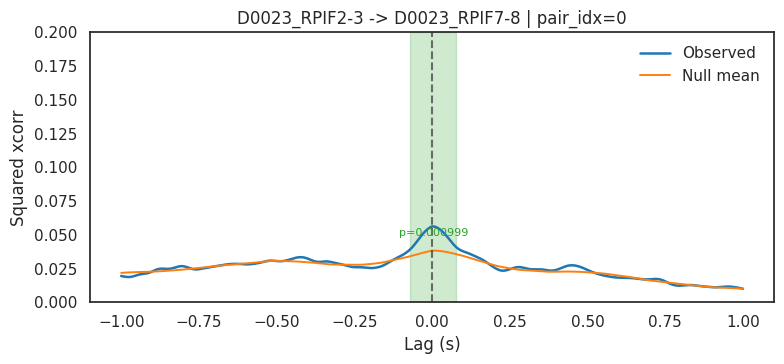

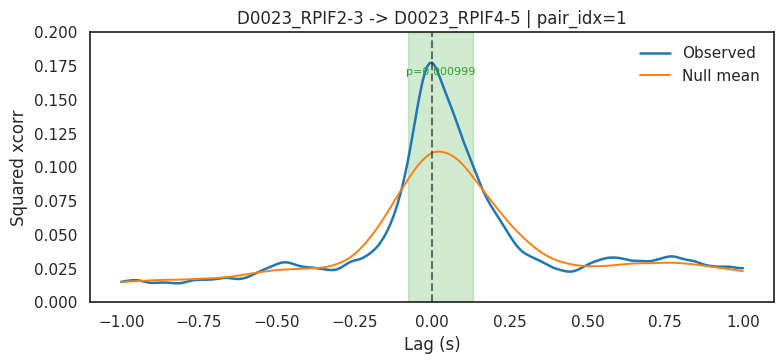

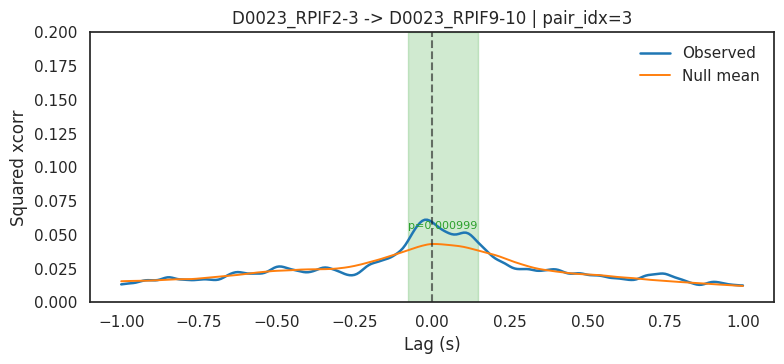

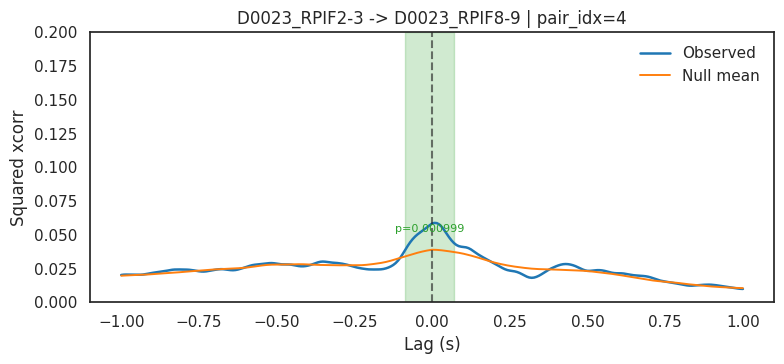

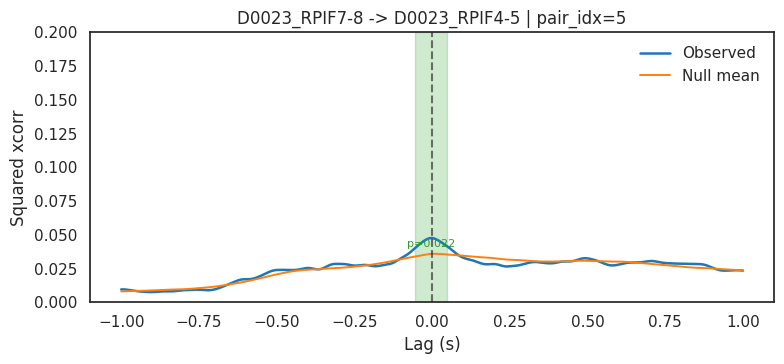

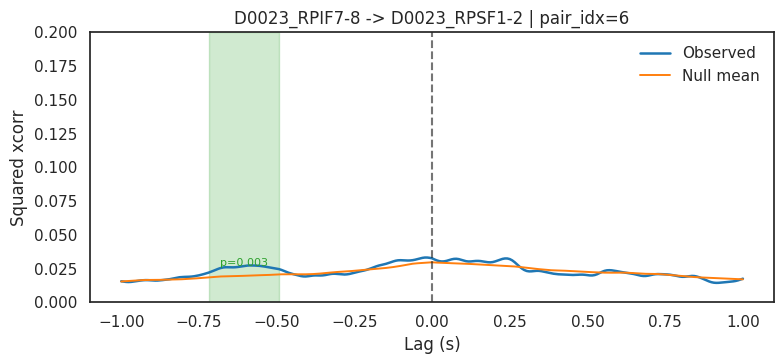

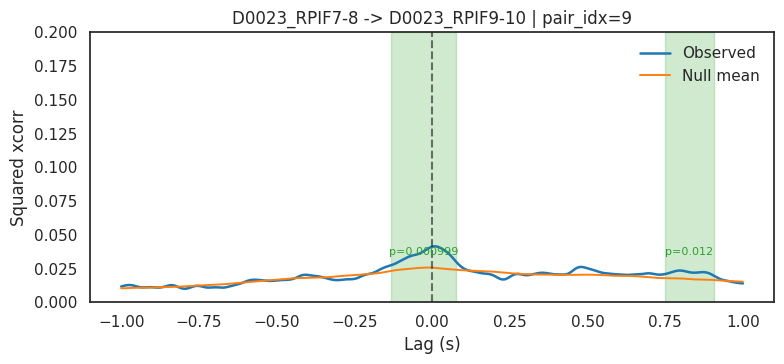

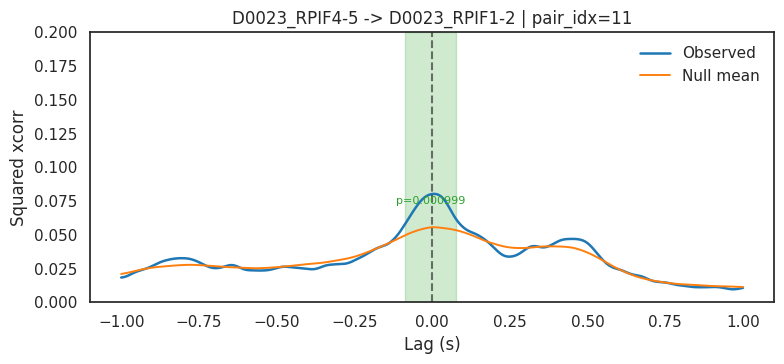

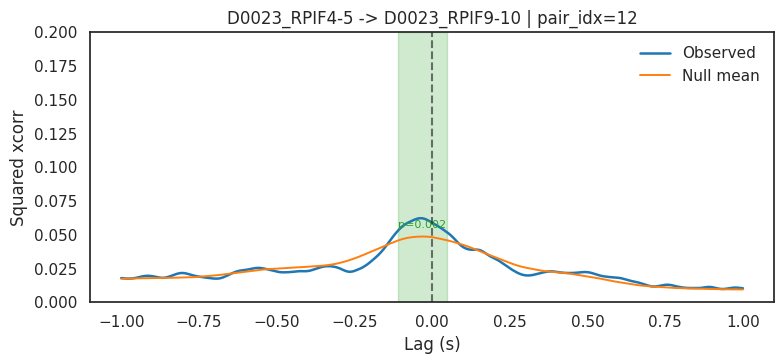

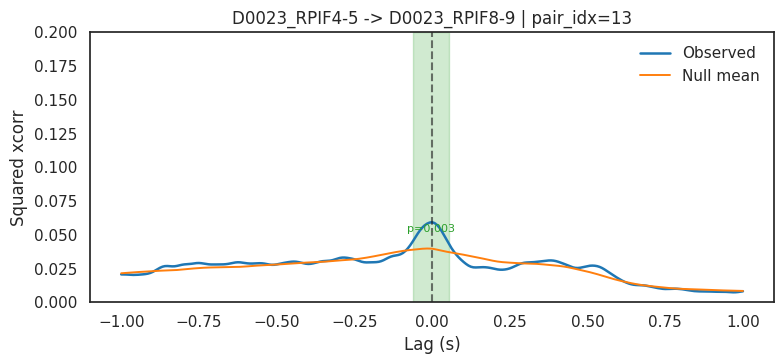

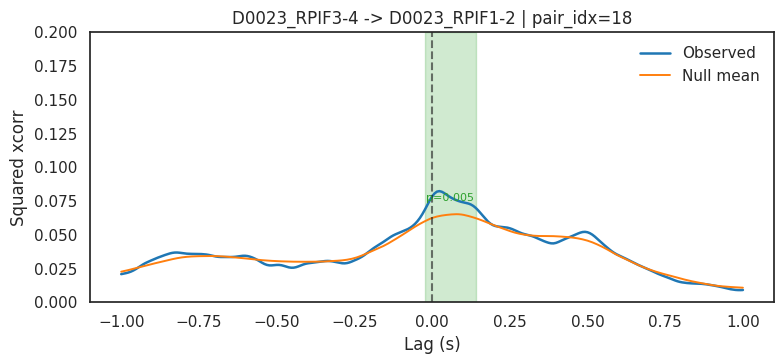

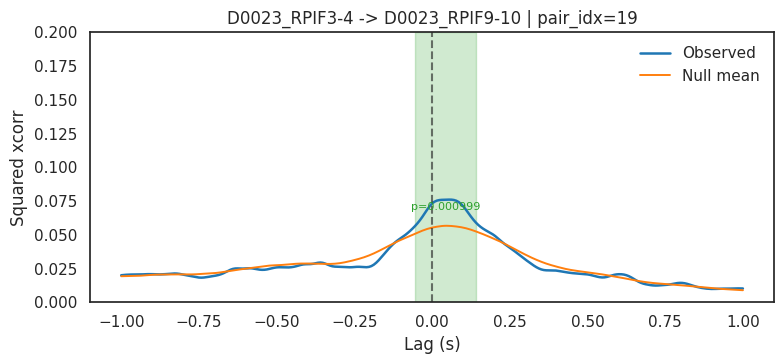

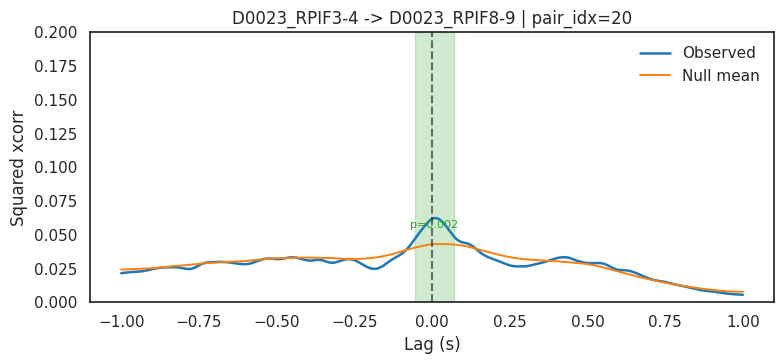

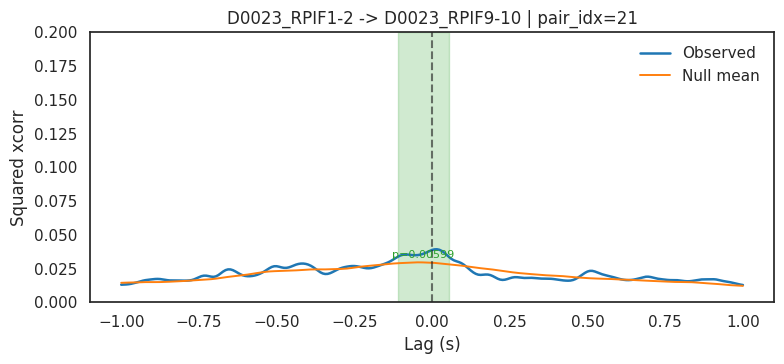

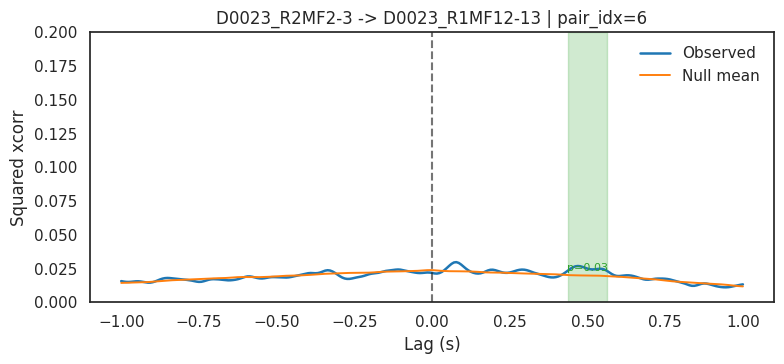

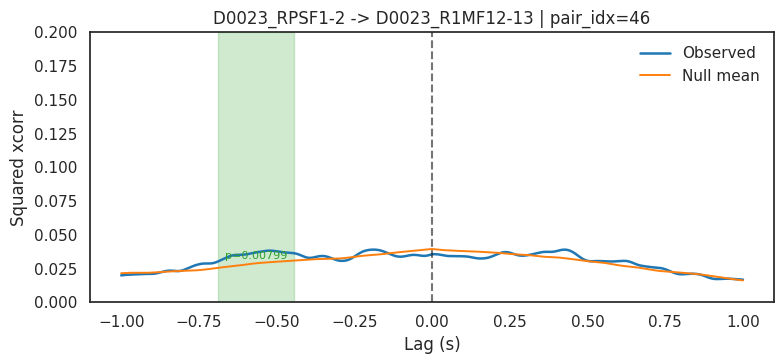

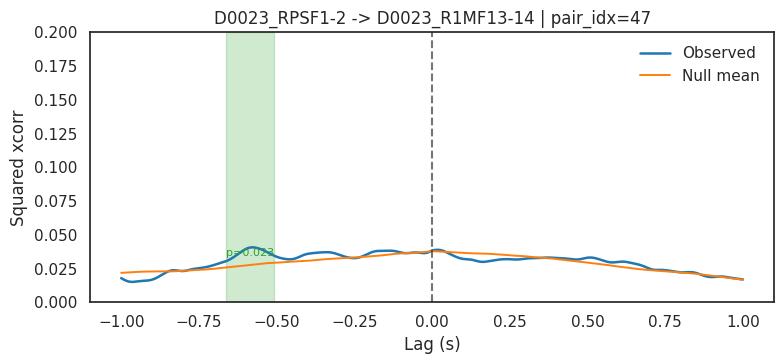

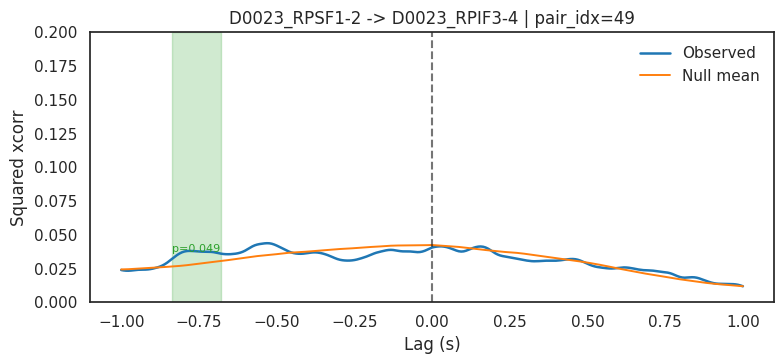

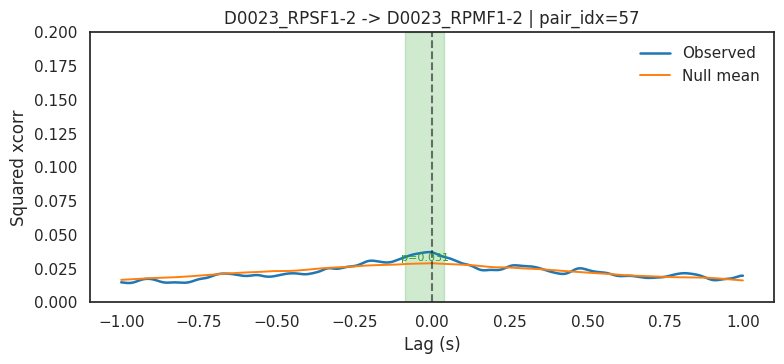

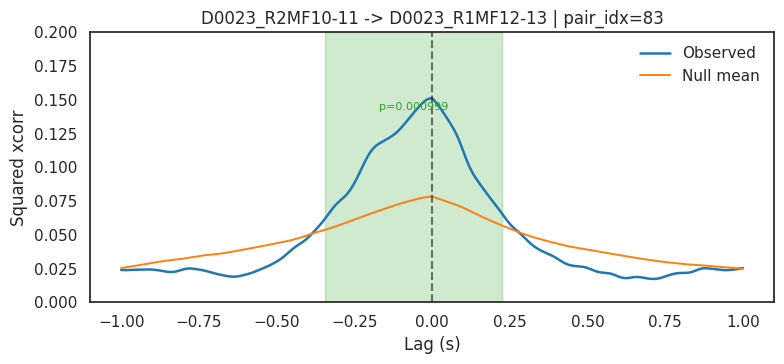

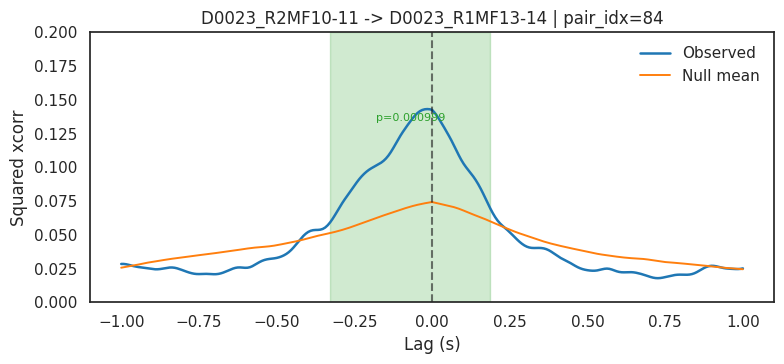

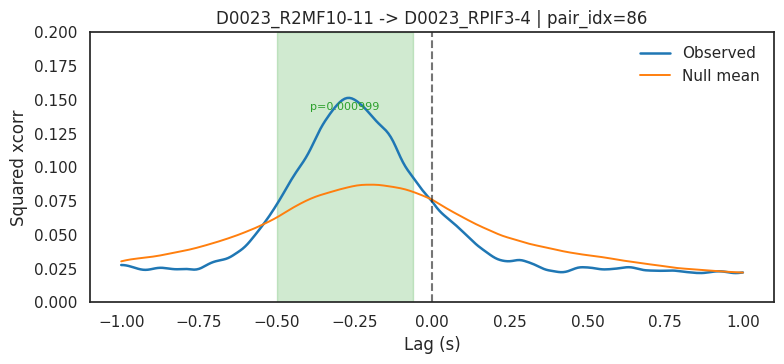

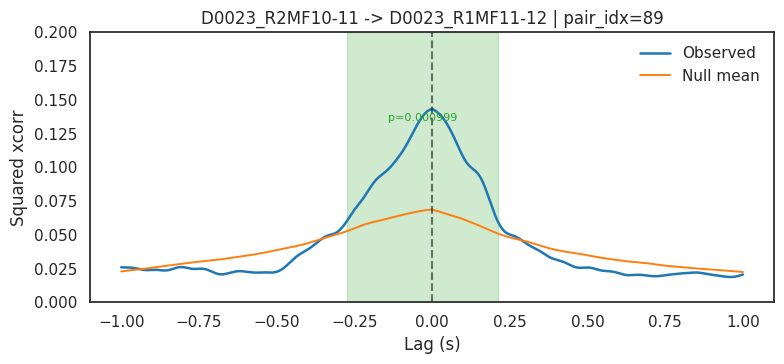

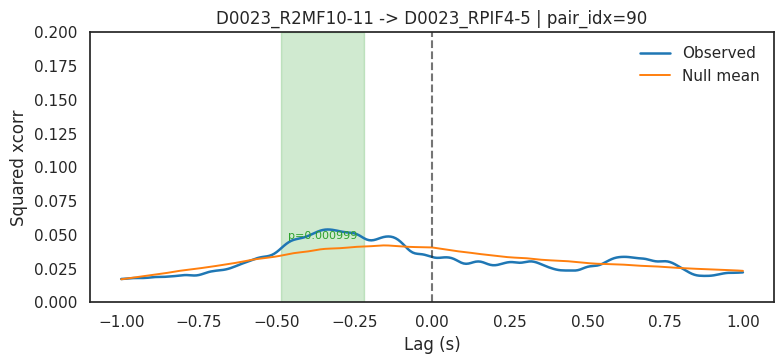

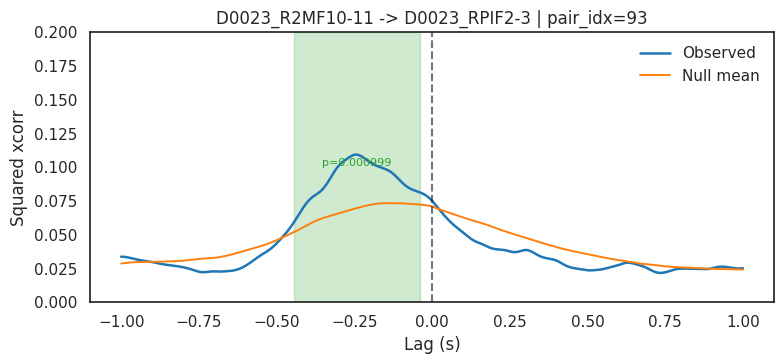

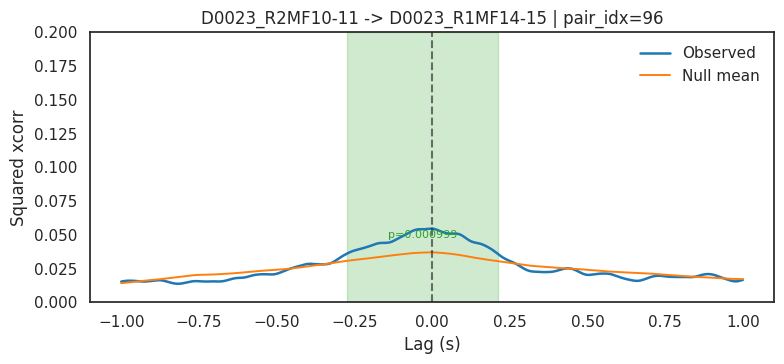

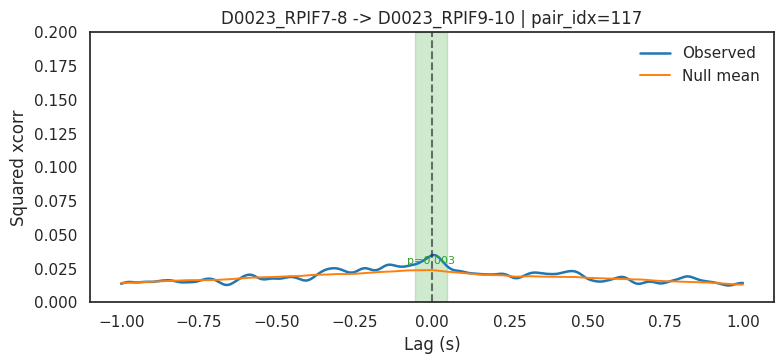

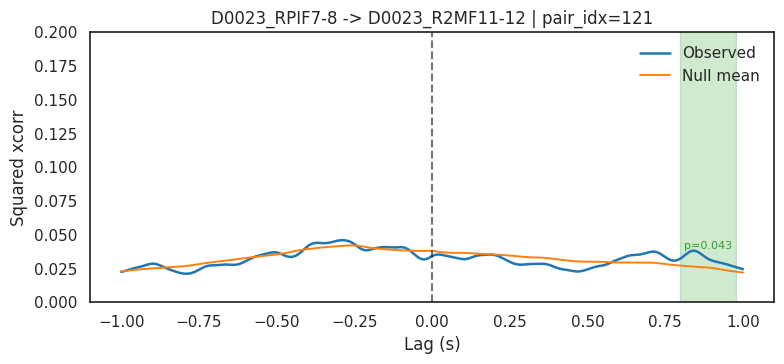

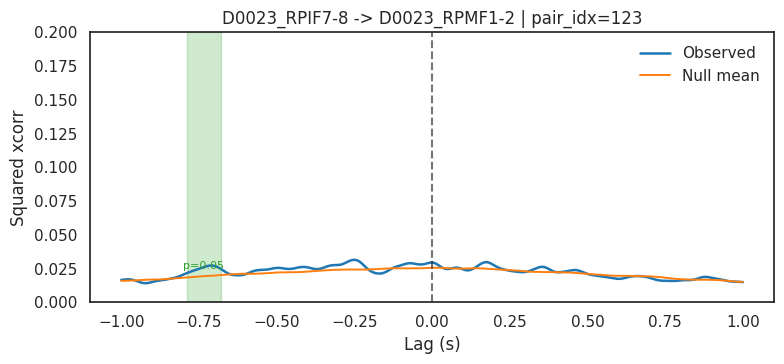

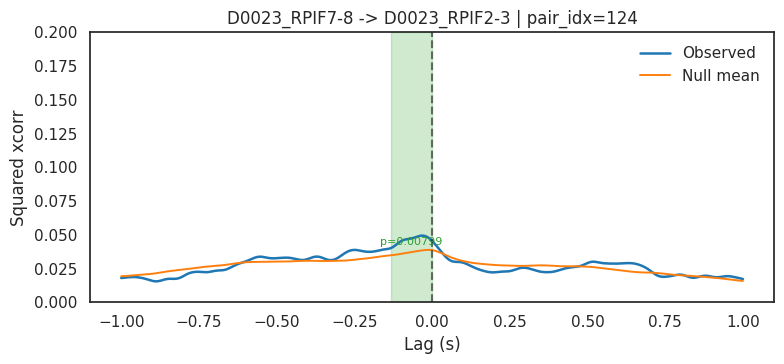

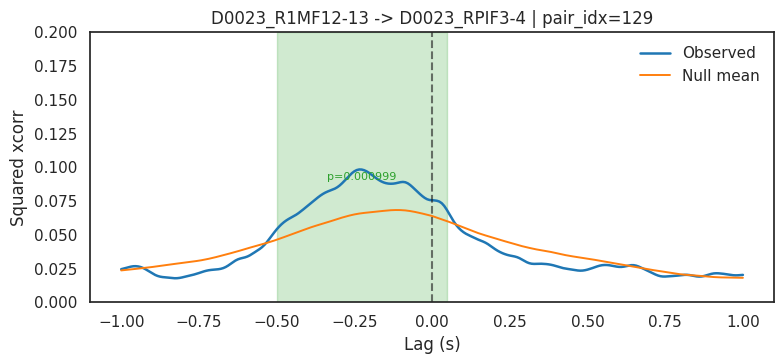

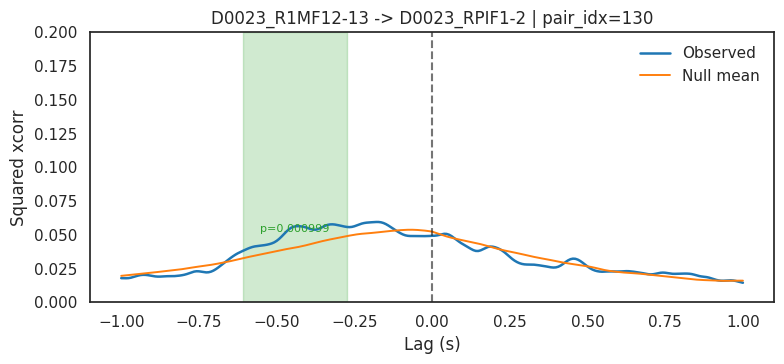

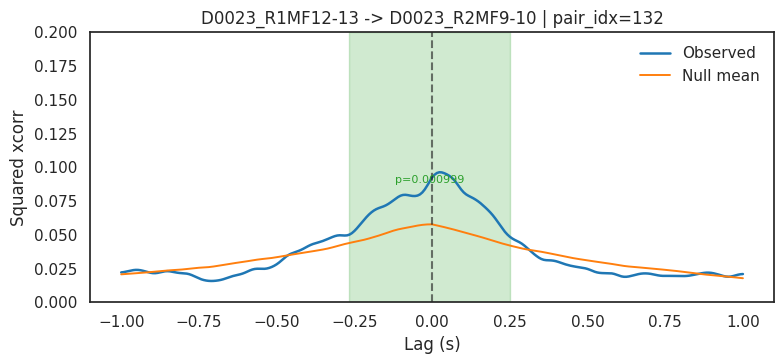

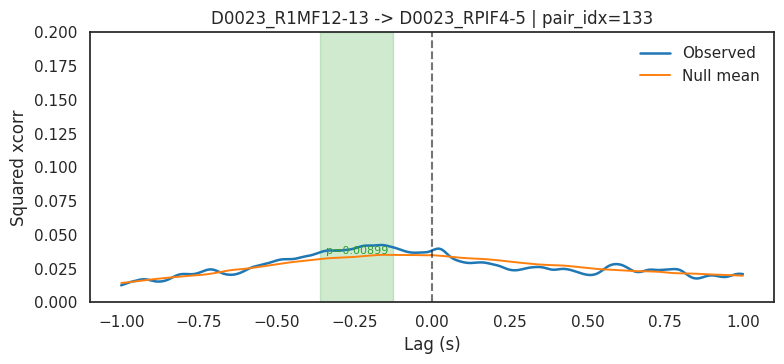

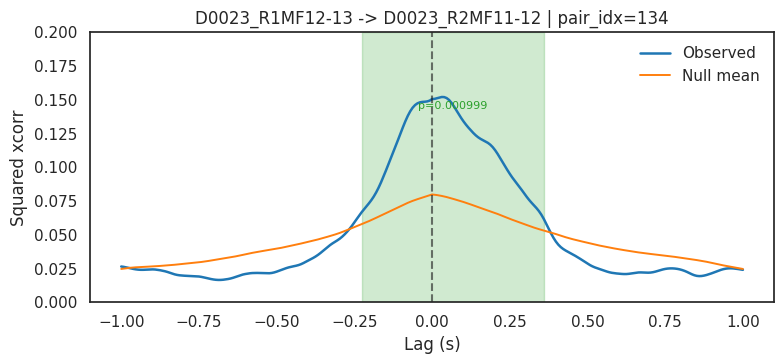

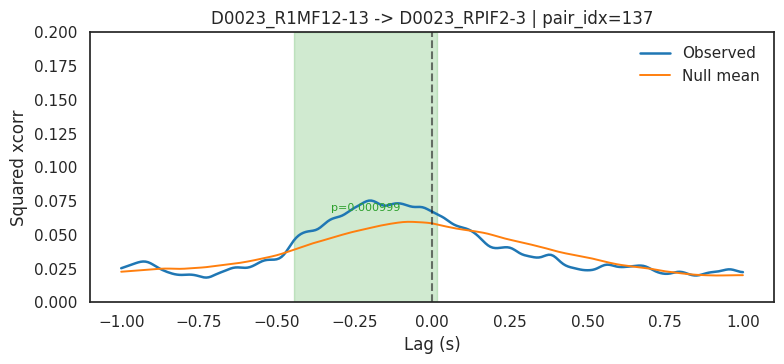

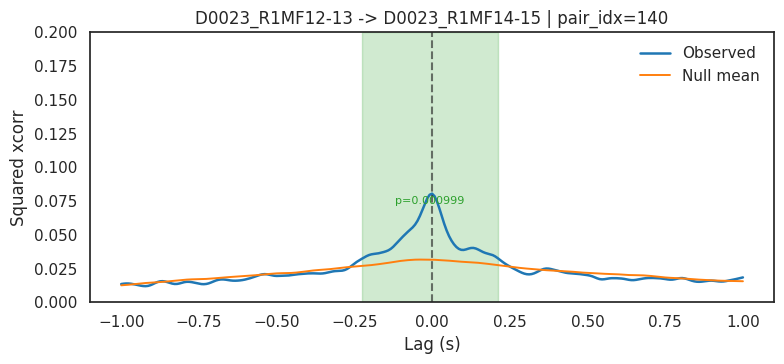

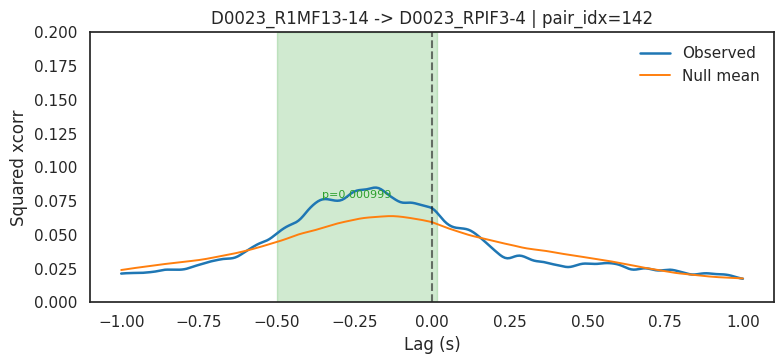

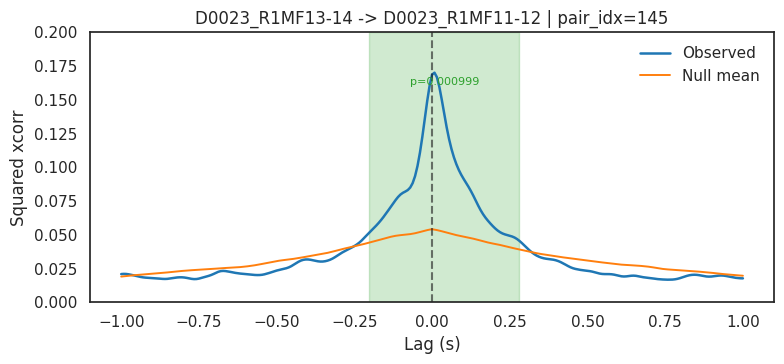

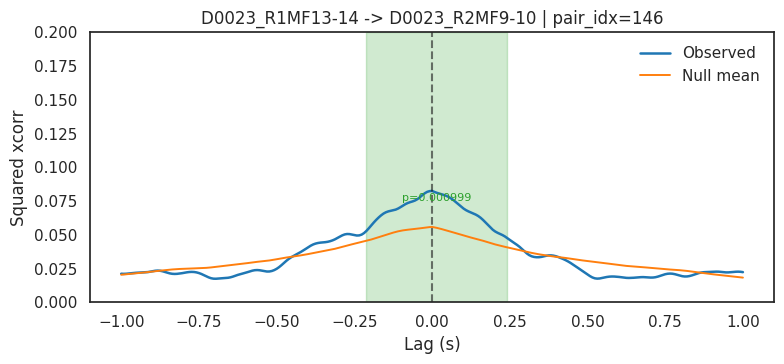

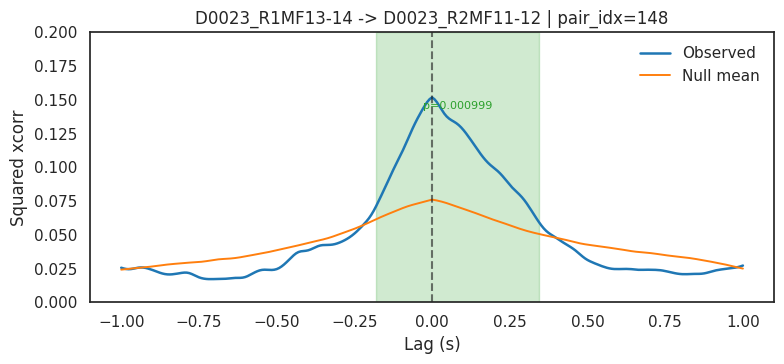

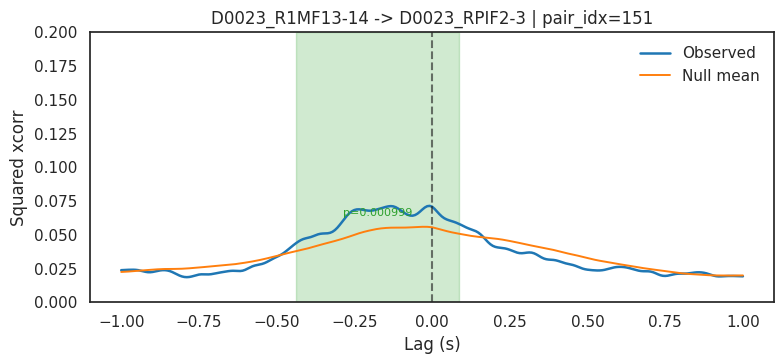

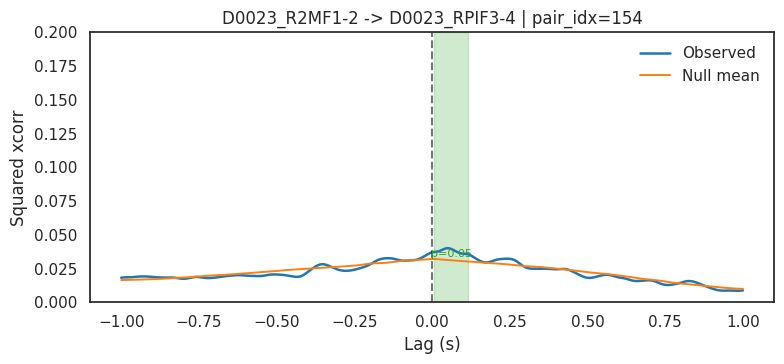

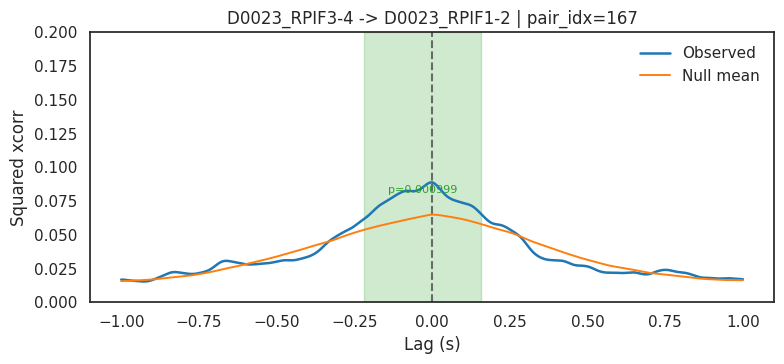

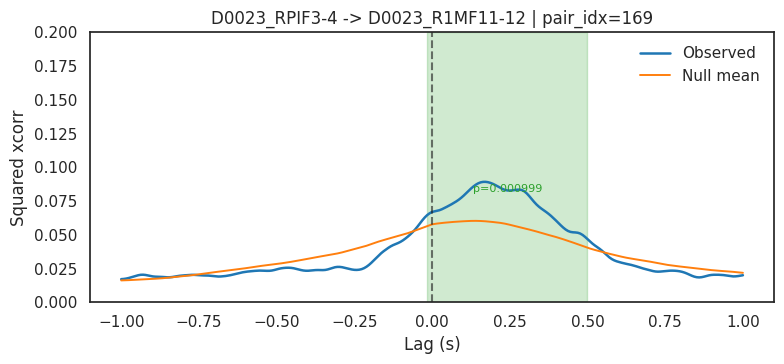

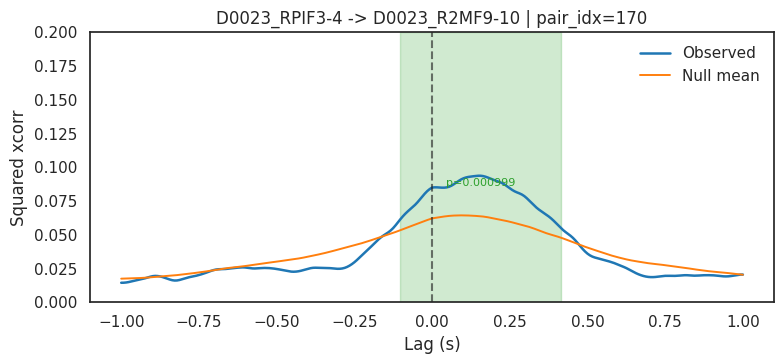

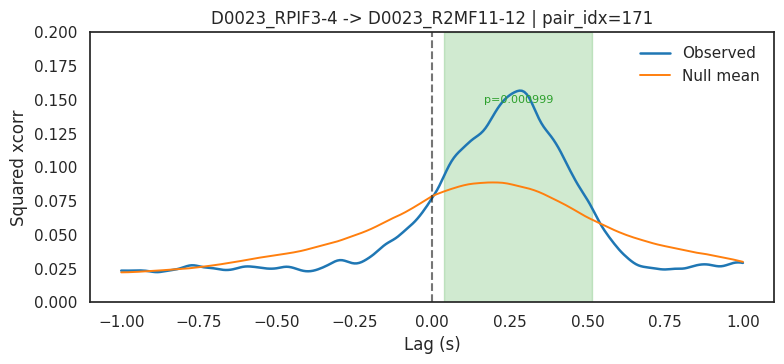

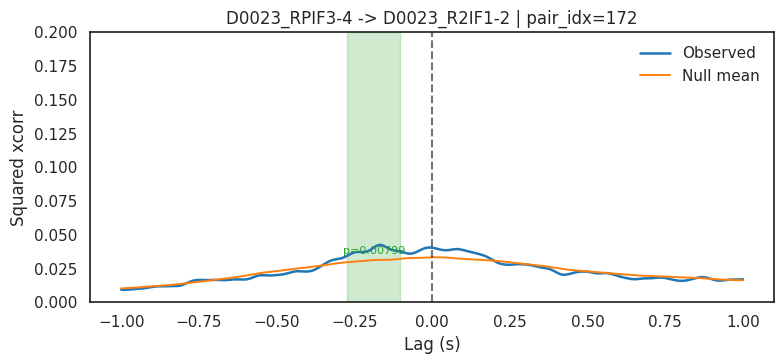

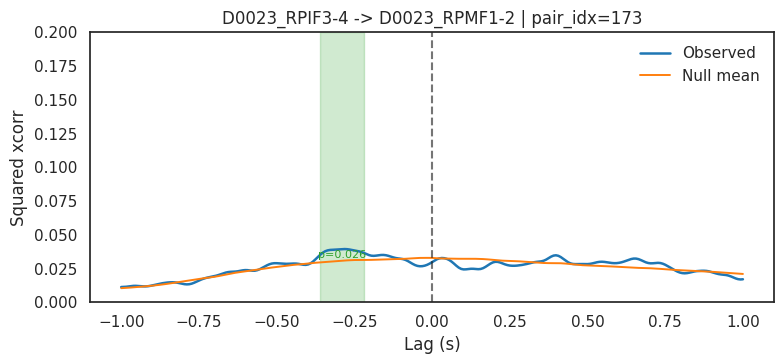

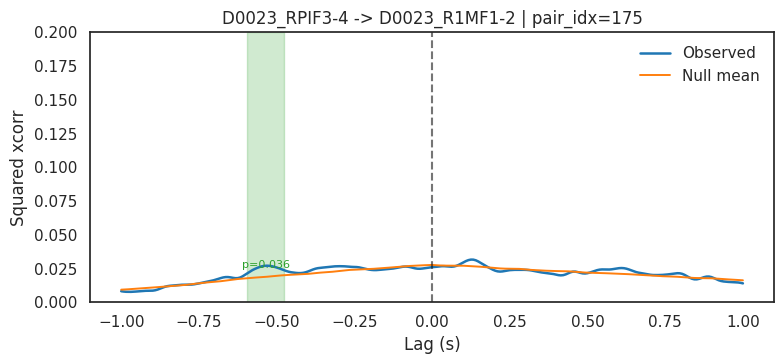

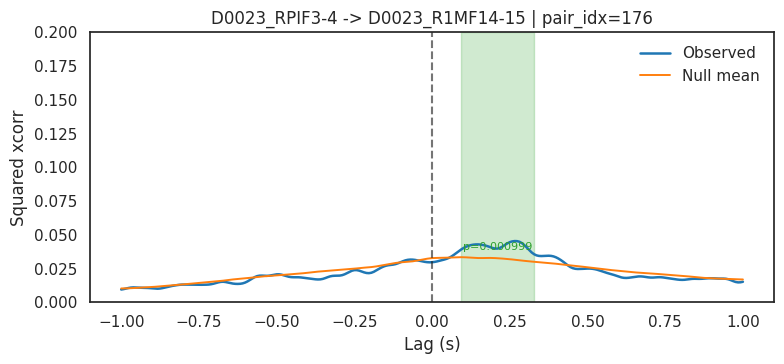

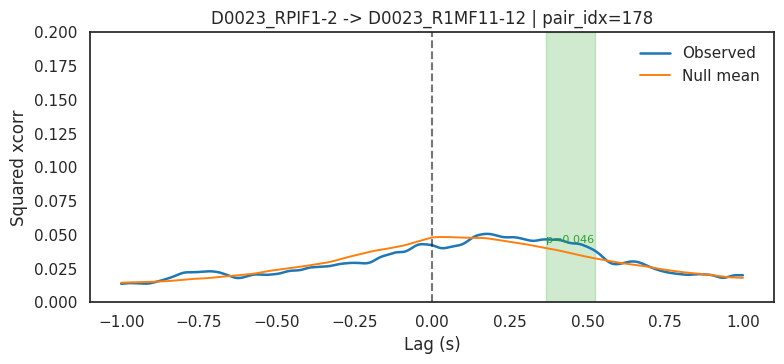

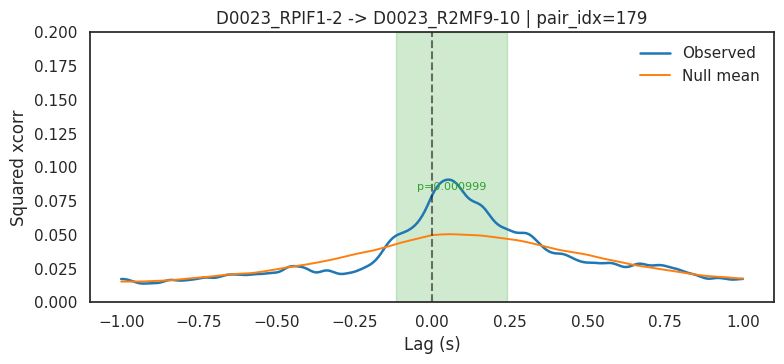

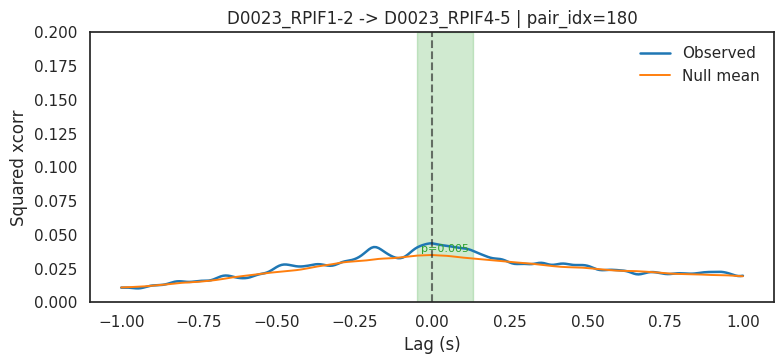

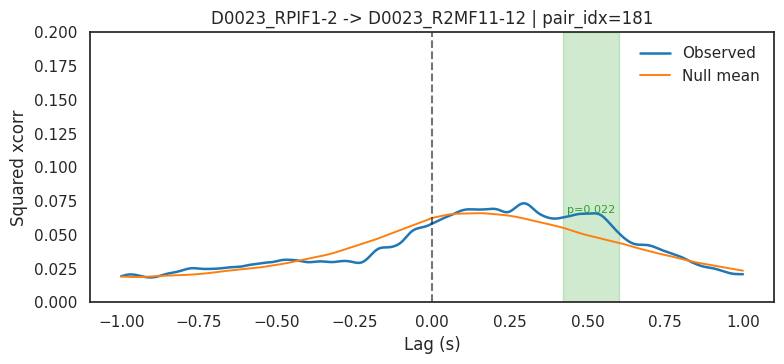

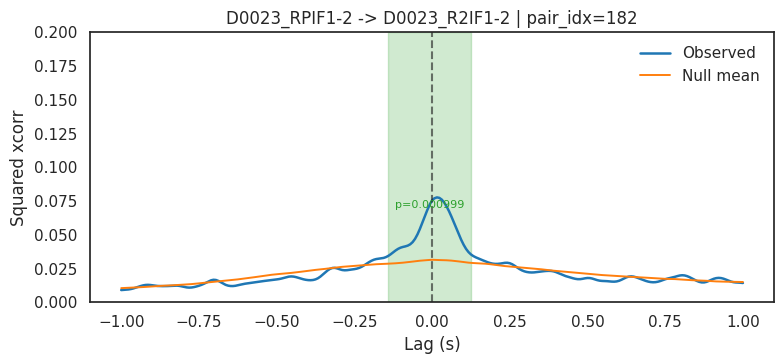

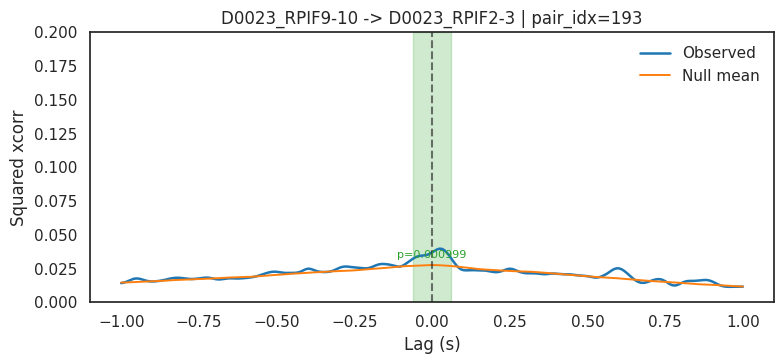

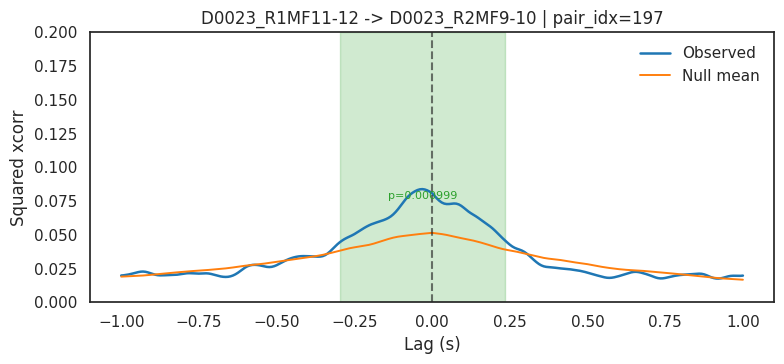

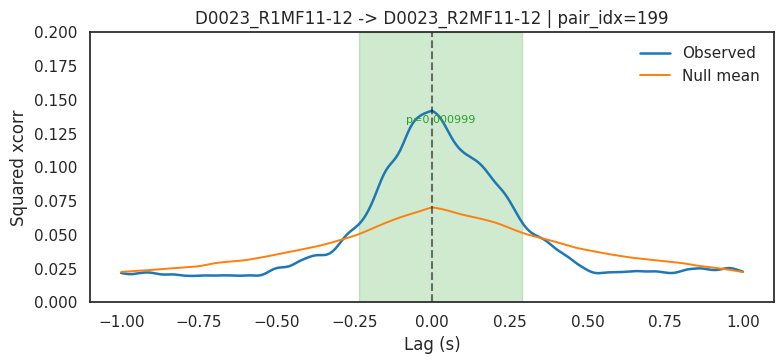

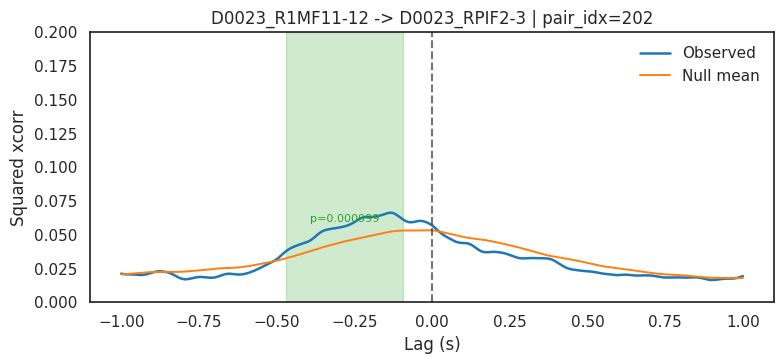

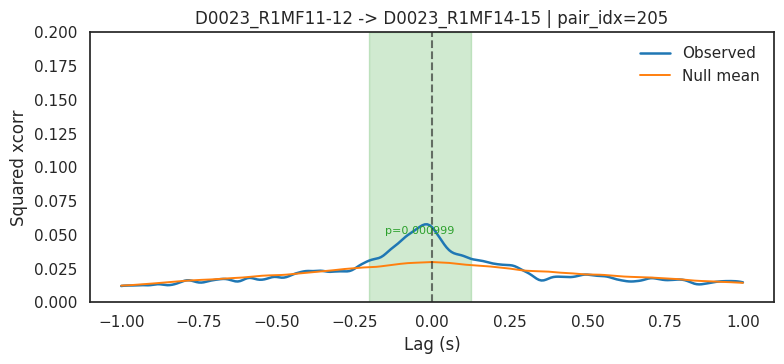

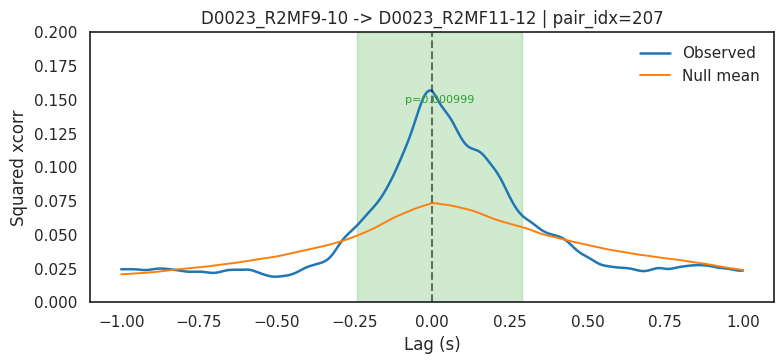

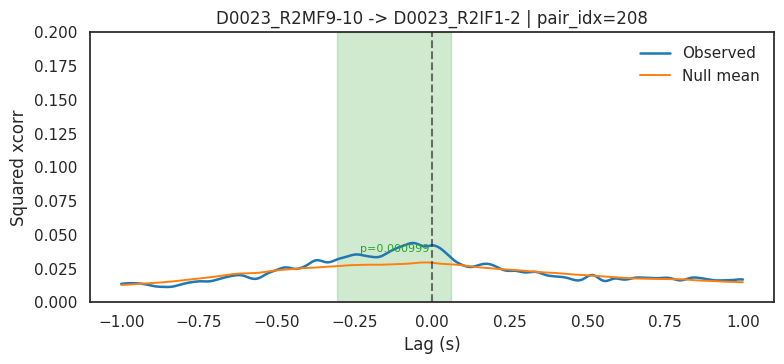

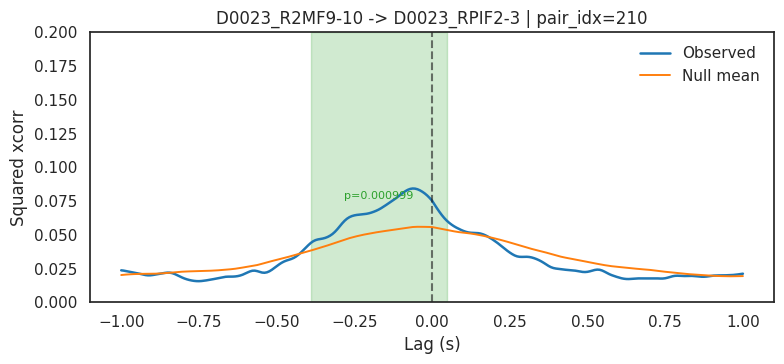

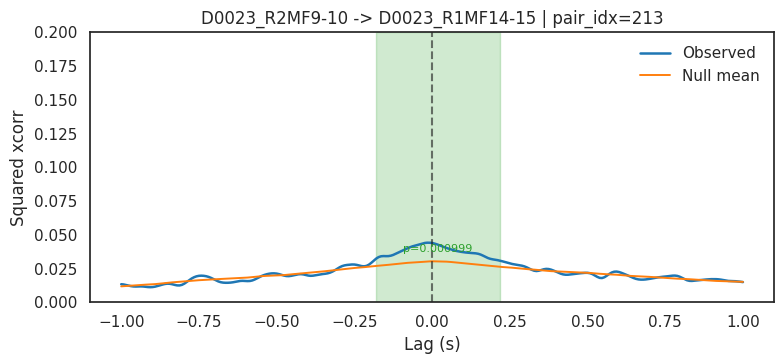

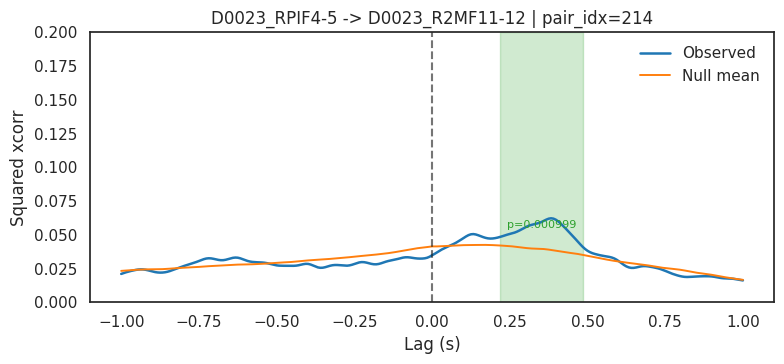

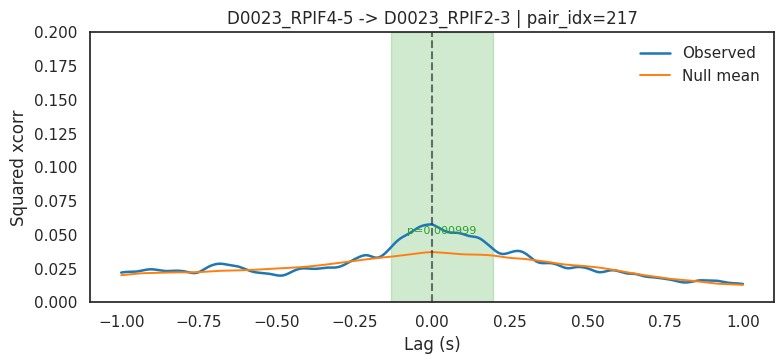

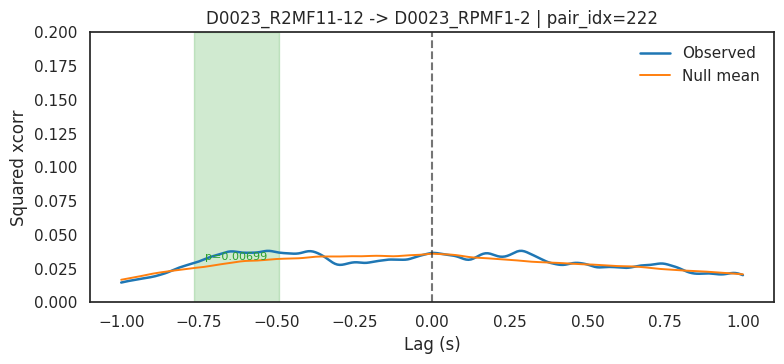

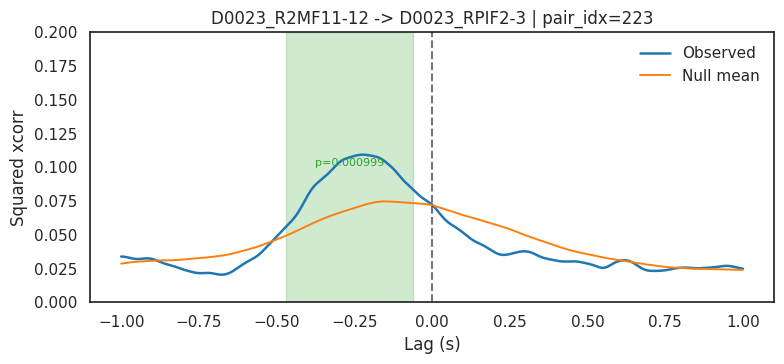

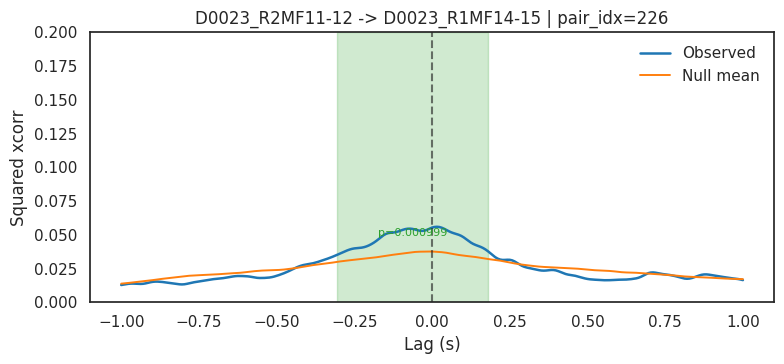

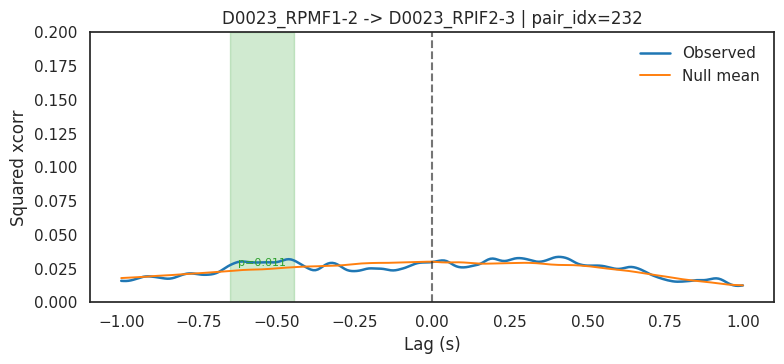

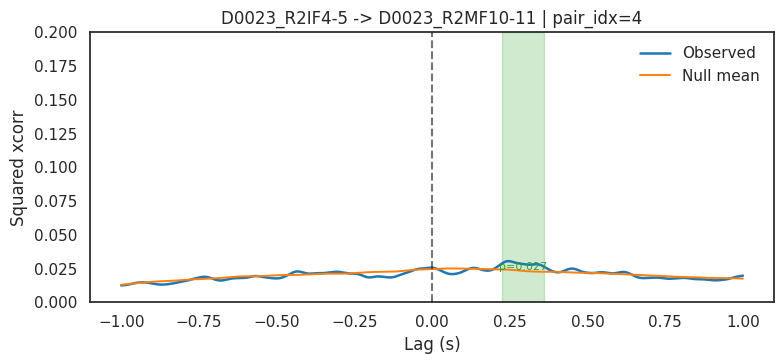

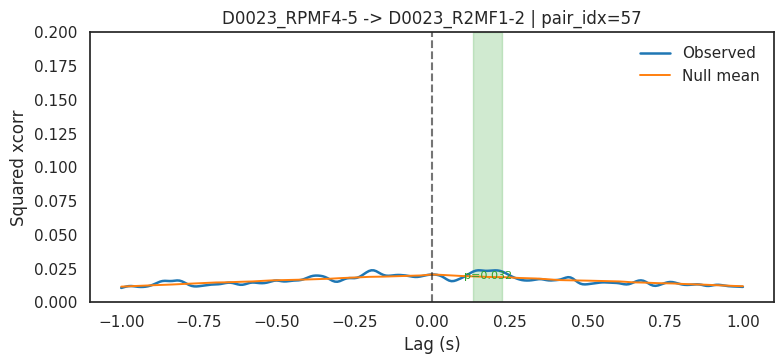

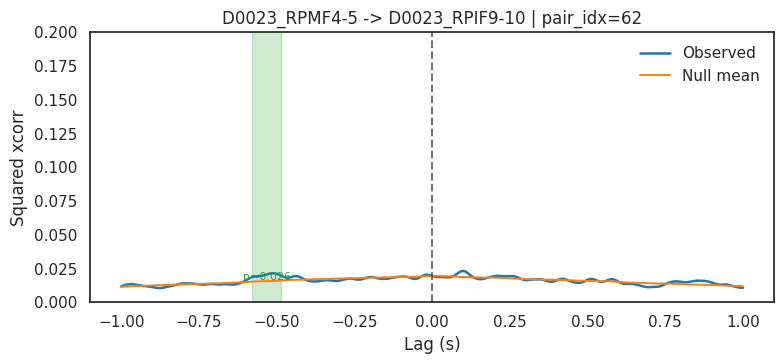

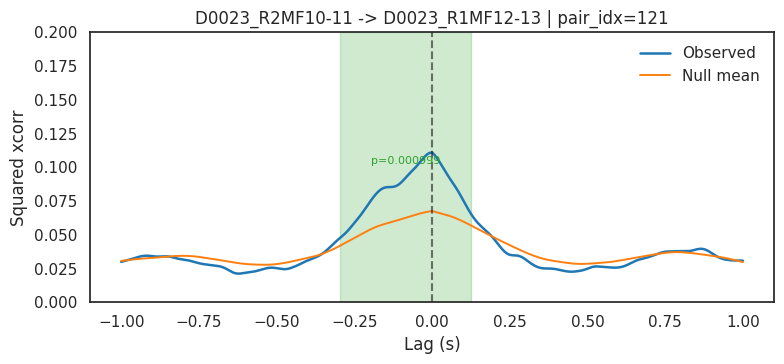

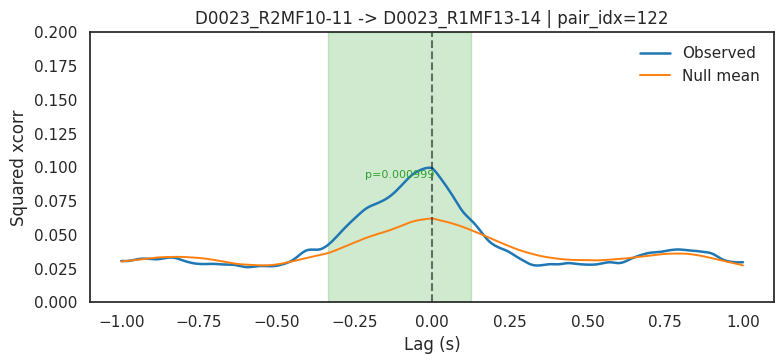

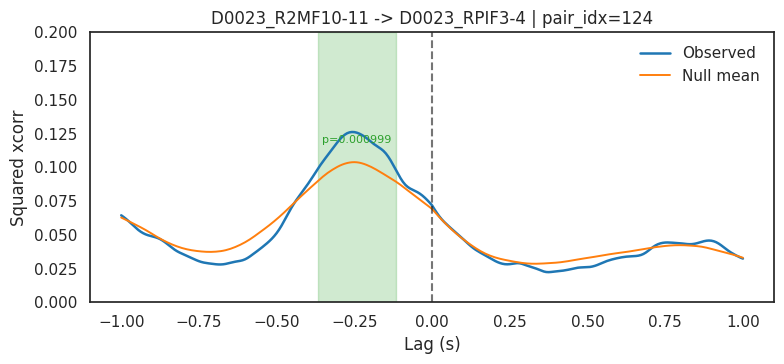

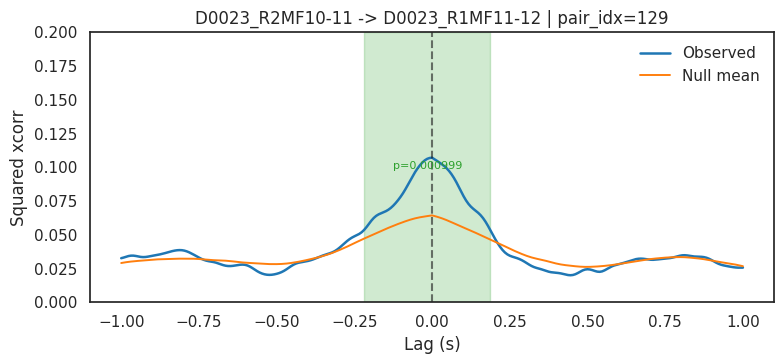

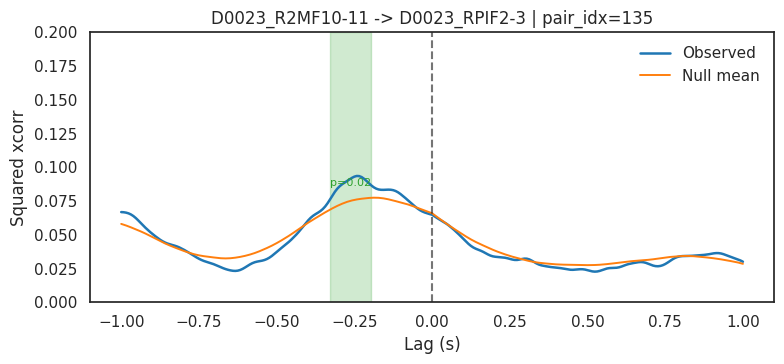

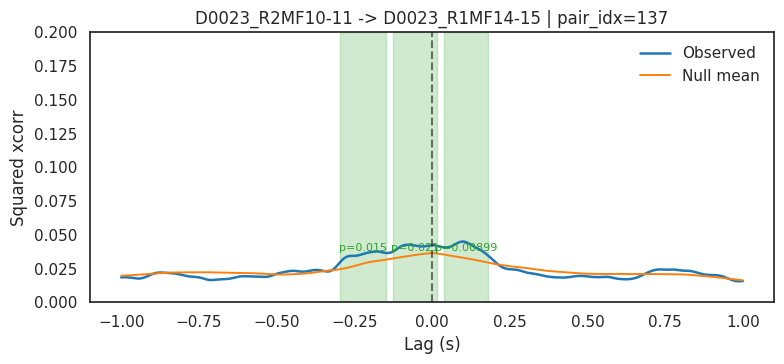

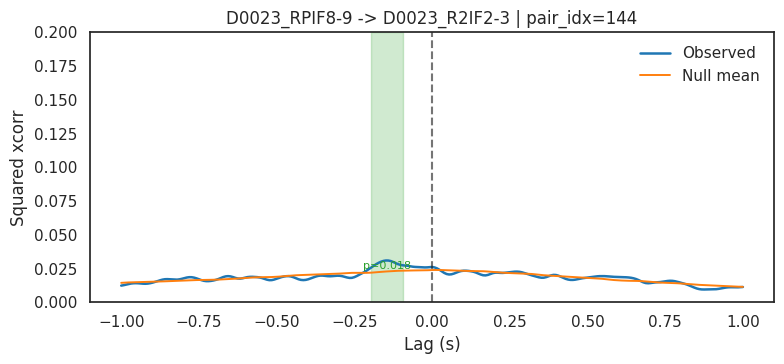

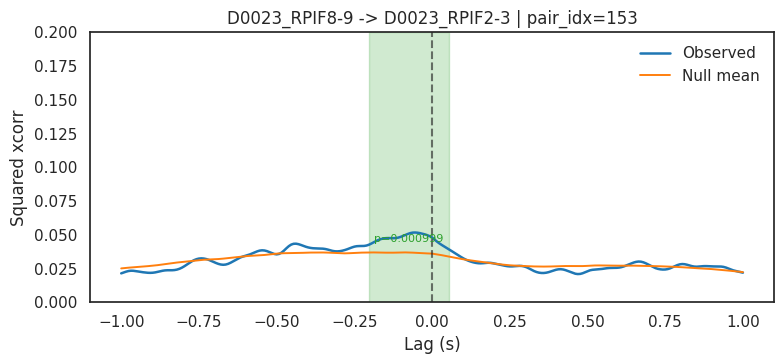

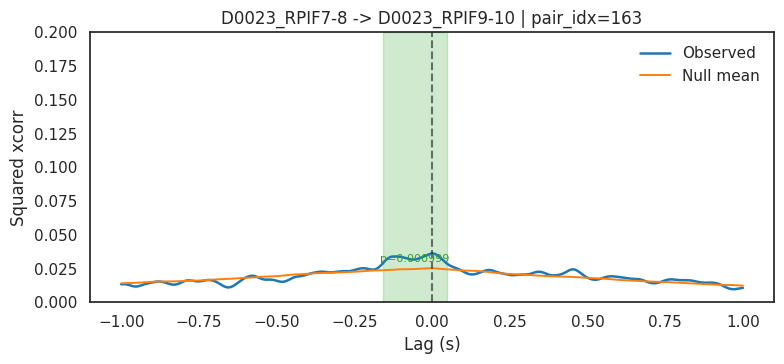

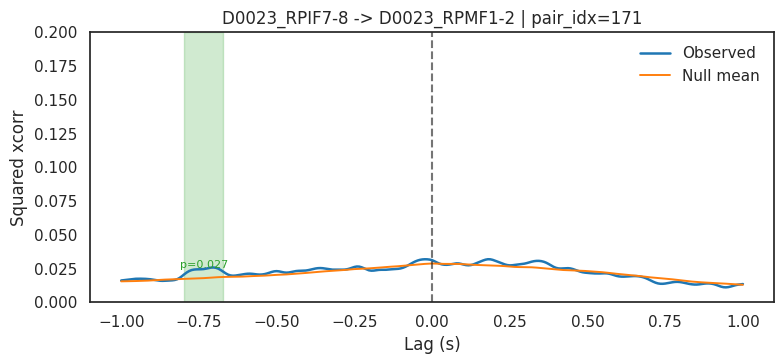

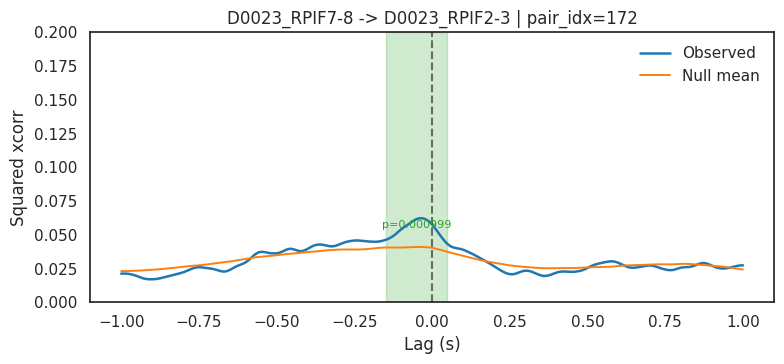

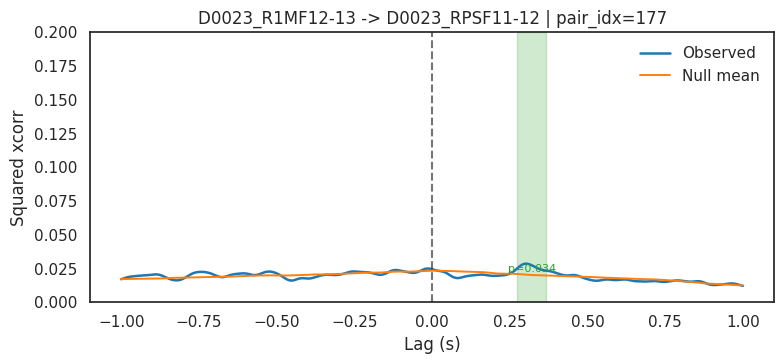

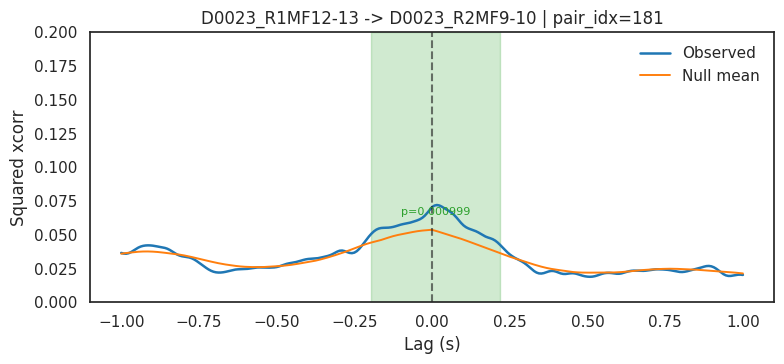

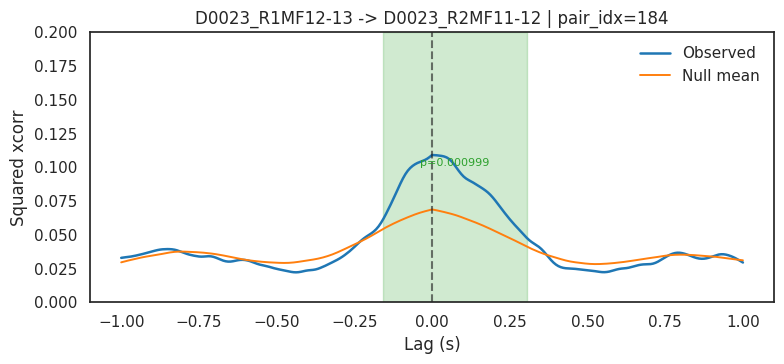

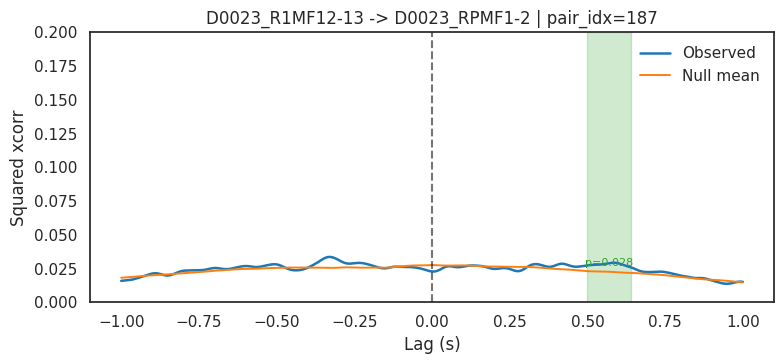

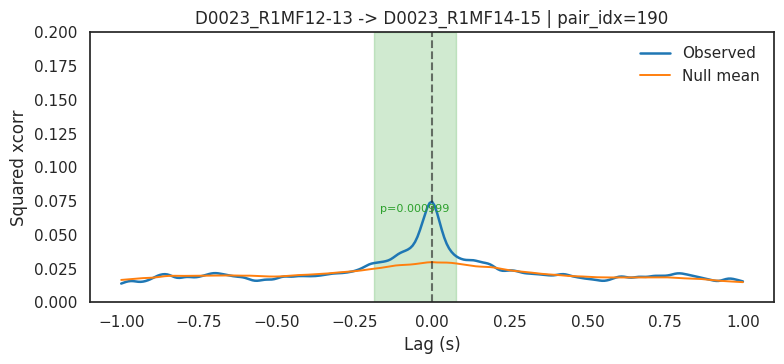

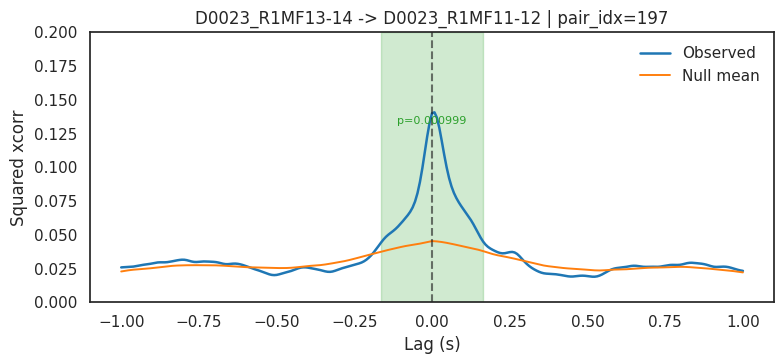

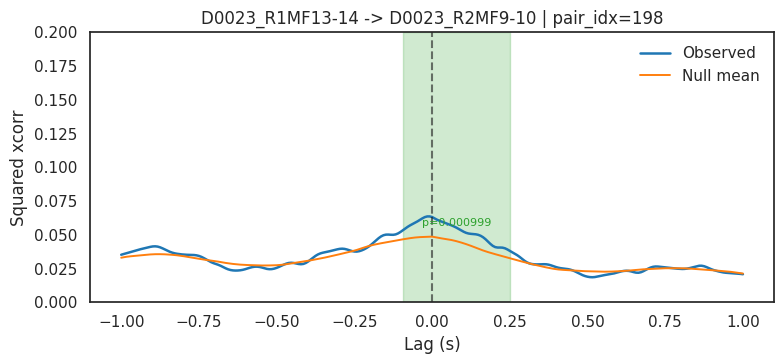

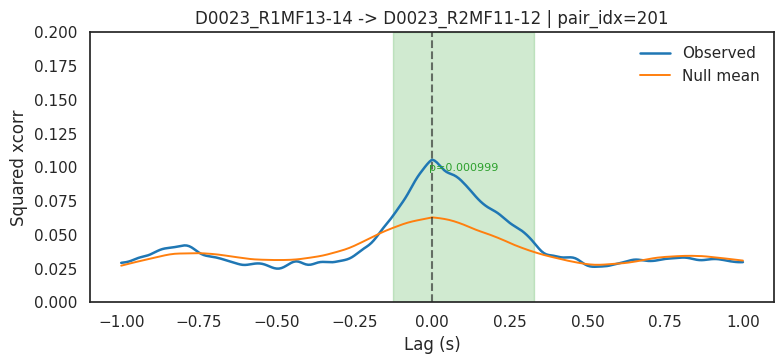

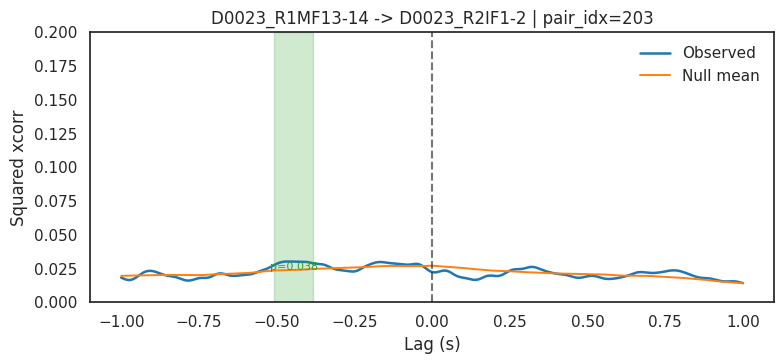

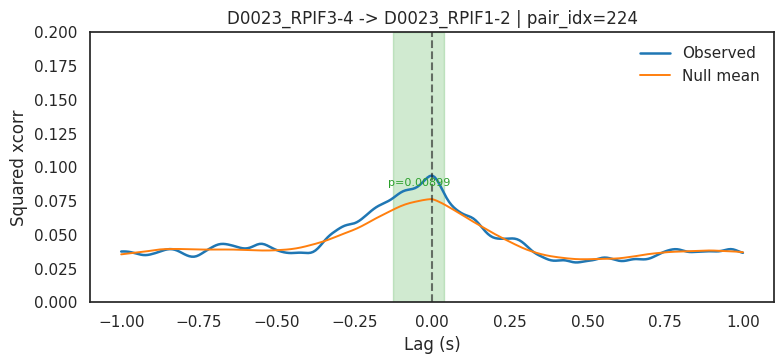

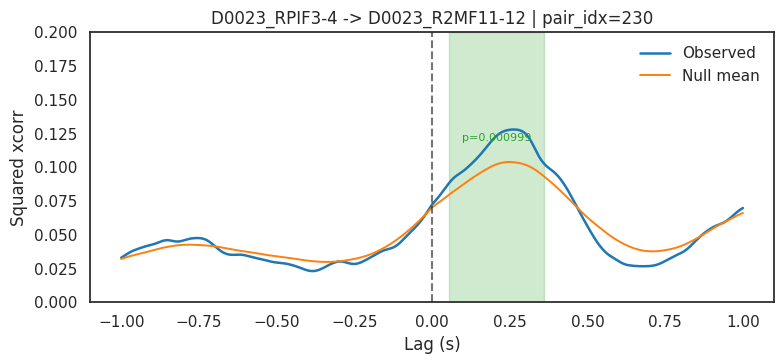

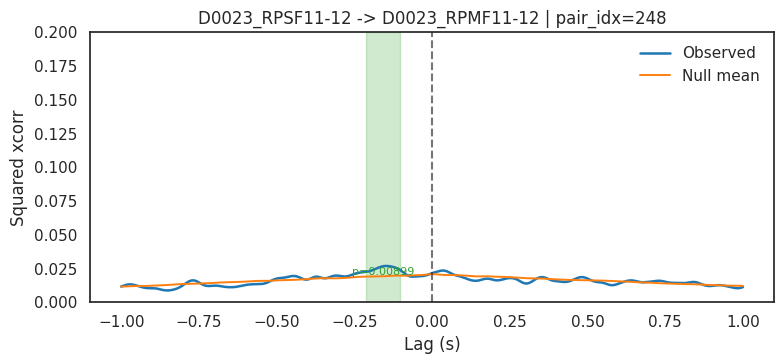

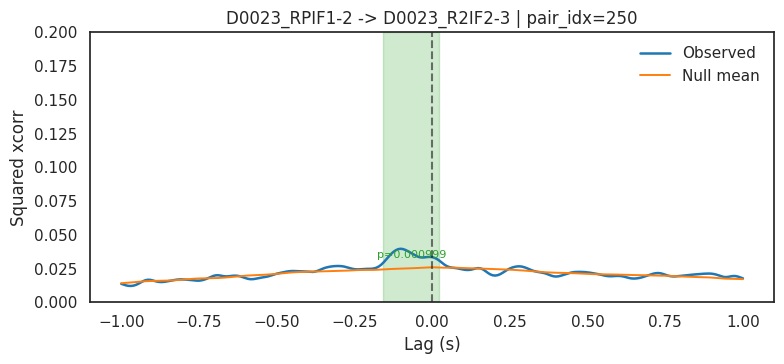

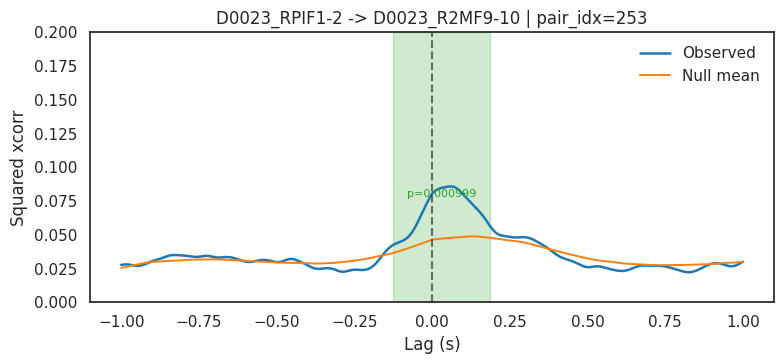

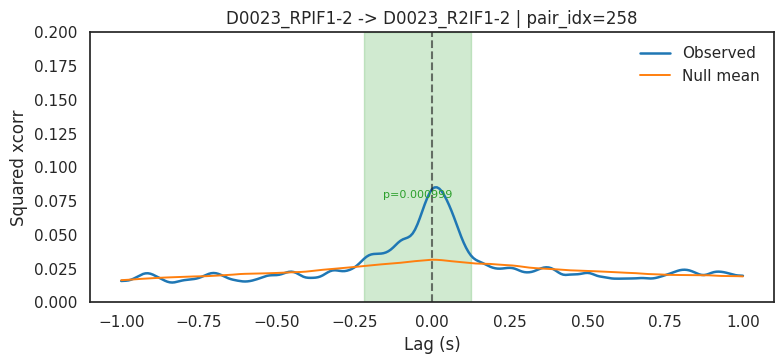

In [91]:
# Plot all significant pairs (NO averaging), and mark every significant cluster
if ds_all is None:
    raise RuntimeError("No xcorr datasets loaded. Run previous cell first.")
if clusters_df.empty:
    raise RuntimeError("No significant clusters found in current query.")

# Keep significant rows only and build NC path from CSV path
sig = clusters_df.copy()
sig = sig[sig["significant"] == True].copy()
if sig.empty:
    raise RuntimeError("clusters_df exists but no rows marked significant=True")

sig["nc_file"] = sig["file"].str.replace(".csv", ".nc", regex=False)
sig["pair_idx"] = sig["pair_idx"].astype(int)

# Group by (file, pair) => one figure per significant pair
pair_groups = (
    sig.groupby(["nc_file", "pair_idx", "source_channel", "target_channel"], as_index=False)
       .size()
       .drop(columns="size")
)

print(f"Significant pairs to plot: {len(pair_groups)}")

# Cache datasets to avoid repeated I/O
ds_cache = {}

for _, g in pair_groups.head(100).iterrows():
    nc_file = g["nc_file"]
    pair_idx = int(g["pair_idx"])
    source_ch = g["source_channel"]
    target_ch = g["target_channel"]

    if nc_file not in ds_cache:
        ds_cache[nc_file] = xr.load_dataset(nc_file)

    ds = ds_cache[nc_file]

    # Guard against out-of-range pair index
    if pair_idx < 0 or pair_idx >= ds.sizes["pair"]:
        print(f"Skip out-of-range pair_idx={pair_idx} in {nc_file}")
        continue

    obs = ds["observed_curve"].isel(pair=pair_idx).values
    nul = ds["null_mean"].isel(pair=pair_idx).values
    thr = ds["point_threshold"].isel(pair=pair_idx).values
    pnt = ds["pointwise_p"].isel(pair=pair_idx).values
    lag = ds["lag"].values

    # Skip if this pair is fully invalid
    if not np.isfinite(obs).any():
        print(f"Skip all-NaN pair: {source_ch} -> {target_ch} ({pair_idx})")
        continue

    fig, ax = plt.subplots(figsize=(8, 3.8))
    ax.plot(lag, obs, lw=1.8, color="tab:blue", label="Observed")
    ax.plot(lag, nul, lw=1.4, color="tab:orange", label="Null mean")
    # ax.plot(lag, thr, lw=1.2, color="tab:red", alpha=0.85, label="Point threshold")
    ax.axvline(0, ls="--", color="k", alpha=0.6)

    # Mark all significant clusters for this pair
    rows = sig[(sig["nc_file"] == nc_file) & (sig["pair_idx"] == pair_idx)]
    for _, r in rows.iterrows():
        x0 = float(r["lag_start_s"])
        x1 = float(r["lag_end_s"])
        pv = float(r["p_value"])
        ax.axvspan(x0, x1, color="tab:green", alpha=0.22)
        ax.text(
            x=(x0 + x1) / 2,
            y=np.nanmax(obs) * 0.98 if np.isfinite(obs).any() else 0.0,
            s=f"p={pv:.3g}",
            ha="center",
            va="top",
            fontsize=8,
            color="tab:green",
        )
        
    ax.set_ylim(0, 0.2)

    ax.set_title(f"{source_ch} -> {target_ch} | pair_idx={pair_idx}")
    ax.set_xlabel("Lag (s)")
    ax.set_ylabel("Squared xcorr")
    ax.legend(frameon=False, loc="upper right")
    plt.tight_layout()
    plt.show()

In [ ]:
# Merge HGA channel ROI into xcorr cluster table
# Keep your loading cell unchanged; this cell only adds source_roi / target_roi.

if clusters_df.empty:
    raise RuntimeError("clusters_df is empty. Run xcorr loading cell first.")
if HGAs.empty:
    raise RuntimeError("HGAs is empty. Run HGA loading/classification cells first.")

# Restrict HGA metadata to the same analysis context (optional but cleaner)
hga_meta = HGAs.copy()
hga_meta = hga_meta[hga_meta["task"] == task].copy()  # task from xcorr cell, e.g. 'LexicalDelay'
hga_meta = hga_meta[hga_meta["phase"] == phase.lower()].copy()  # HGA phase is lower-case
hga_meta = hga_meta[hga_meta["description"].isin(descriptions)].copy()

# One channel -> one ROI mapping
# If a channel appears multiple times, use the most frequent ROI
roi_mode = (
    hga_meta.groupby(["channel", "roi"], as_index=False)
    .size()
    .sort_values(["channel", "size"], ascending=[True, False])
    .drop_duplicates(subset=["channel"], keep="first")
    [["channel", "roi"]]
)

# Optional: keep label/coordinates from first appearance
chan_meta_first = (
    hga_meta.sort_values(["channel"]) 
    .drop_duplicates(subset=["channel"], keep="first")
    [["channel", "label", "x", "y", "z", "subject"]]
)

channel_map = roi_mode.merge(chan_meta_first, on="channel", how="left")

# Merge to cluster rows
clusters_roi_df = clusters_df.copy()

clusters_roi_df = clusters_roi_df.merge(
    channel_map.add_prefix("source_").rename(columns={"source_channel": "source_channel"}),
    on="source_channel",
    how="left",
)
clusters_roi_df = clusters_roi_df.merge(
    channel_map.add_prefix("target_").rename(columns={"target_channel": "target_channel"}),
    on="target_channel",
    how="left",
)

# Helpful flags for QC
clusters_roi_df["source_roi_missing"] = clusters_roi_df["source_roi"].isna()
clusters_roi_df["target_roi_missing"] = clusters_roi_df["target_roi"].isna()

print("Total cluster rows:", len(clusters_roi_df))
print("Missing source_roi:", int(clusters_roi_df["source_roi_missing"].sum()))
print("Missing target_roi:", int(clusters_roi_df["target_roi_missing"].sum()))

# Show missing channels (if any)
missing_source = sorted(clusters_roi_df.loc[clusters_roi_df["source_roi_missing"], "source_channel"].dropna().unique())
missing_target = sorted(clusters_roi_df.loc[clusters_roi_df["target_roi_missing"], "target_channel"].dropna().unique())
if missing_source:
    print("Unmatched source channels (first 20):", missing_source[:20])
if missing_target:
    print("Unmatched target channels (first 20):", missing_target[:20])

# Significant-only view for downstream analysis
sig_roi_df = clusters_roi_df[clusters_roi_df["significant"] == True].copy()

display(
    sig_roi_df[
        [
            "pair_idx", "source_channel", "source_roi", "target_channel", "target_roi",
            "lag_start_s", "lag_end_s", "mass", "p_value", "file"
        ]
    ].head(10)
)